In [ ]:
# USER-SPECIFIC: The folder path holding CWatM simulations 
if not 'output_folder' in locals():  
    output_folder = r'C:\nonGithub\Output'

if not 'Modflow' in locals():
    Modflow = False

if not 'limitAbstraction' in locals():
    limitAbstraction = False
    
if not 'consumption' in locals():
    consumption = True
    
if not 'withdrawals' in locals():
    withdrawals = True
    
if not 'sectorSourceAbstractionFractions' in locals():
    sectorSourceAbstractionFractions = True

if not sectorSourceAbstractionFractions:
    withdrawals = False
    consumption = False
    
if not 'withCrops' in locals():
    withCrops = False
    numberOfCrops = 18
    
if not 'Excel' in locals():
    Excel = False
    
if not 'reservoir_transfers' in locals():
    reservoir_transfers = False
    
if not 'israel_model' in locals():
    israel_model = False

if not 'text_inflow' in locals():
    text_inflow = False
    
if not 'dark' in locals():
    dark=True
    

In [2]:
import os
 
# Get the list of all files and directories
output_folder_files = os.listdir(output_folder)

import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma

import plotly
from plotly import graph_objs as go, offline as po, tools
from plotly.subplots import make_subplots
import plotly.express as px

#from PIL import Image
import datetime
import json
import pandas as pd
from netCDF4 import Dataset, num2date

from IPython.display import Image, display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
def commas(num):
    return '{:,.2f}'.format(num)

def geo_idx(dd, dd_array):
   """
     search for nearest decimal degree in an array of decimal degrees and return the index.
     np.argmin returns the indices of minium value along an axis.
     so subtract dd from all values in dd_array, take absolute value and find index of minium.
    """
   geo_idx = (np.abs(dd_array - dd)).argmin()
   return geo_idx

## Discharge at basin outlet

Here, we present the monthly discharge at the outlet of the Nira subbasin.

In [4]:
nc_simulated = Dataset(output_folder + '/totalET_daily.nc', 'r')
Dates_simulation = num2date(nc_simulated.variables['time'][:], units=nc_simulated.variables['time'].units)

In [1]:
# ['CWatm variable name', 'Label', 'Unit', Input/Output/Storage']

# There are three different types of Units: 
# 1. Spatially districuted values in M
# 2. Spatially distributed values in M3
# 3. Summed total for the basin, where each cell holds the total sum for the basin

if Modflow == False:
    Vars = [
        ['storGroundwater',   'Groundwater',       'M',    'Storage'],
        ['storGroundwater',   'Groundwater',       'M',    'Storage_GW'],
        ['sum_capRiseFromGW', 'Capillary rise',    'M',    'Input_GW'],
        ['sum_capRiseFromGW', 'Capillary rise',    'M',    'Output_GW'], 
        ['sum_capRiseFromGW', 'Capillary rise',    'M',    'Output_Soil'],
        ['sum_capRiseFromGW', 'Capillary rise',    'M',    'Input_Soil']]
        
    if limitAbstraction == True:
        Vars.extend([['nonFossilGroundwaterAbs', 'GW pumping', 'M', 'Output_GW']]) #for limitAbstraction
        Vars.extend([['nonFossilGroundwaterAbs', 'GW pumping', 'M', 'Input_Consumption']]) #for limitAbstraction
    else:
        Vars.extend([['unmetDemand',             'Fossil water', 'M', 'Input']]) 
        Vars.extend([['unmetDemand',             'Fossil water', 'M', 'Input_GW']]) 
        #Vars.extend([['unmetDemand',             'Fossil water', 'M', 'Output_GW']]) 
        Vars.extend([['pot_GroundwaterAbstract', 'GW requested', 'M', 'Input_Consumption']])
        
        if not withdrawals:
            Vars.extend([['pot_GroundwaterAbstract', 'GW pumping',   'M', 'Output_GW']])
        else:
            Vars.extend([['GW_Domestic', 'GW_Domestic', 'M', 'Output_GW']])
            Vars.extend([['GW_Livestock',    'GW_Livestock', 'M', 'Output_GW']])
            Vars.extend([['GW_Industry', 'GW_Industry', 'M', 'Output_GW']])
            Vars.extend([['GW_Irrigation', 'GW_Irrigation', 'M', 'Output_GW']])

else:
    Vars = [
        ['leakage',                         'Canal leakage',         'M3','Output_LR'],
        ['capillar',                        'Capillary rise',        'M', 'Output_GW'],
        ['capillar',                        'Capillary rise',        'M', 'Input_Soil'],
        ['modfPumpingM_actual',             'GW pumping actual',     'M', 'Output_GW'],
        ['Pumping_daily',                   'GW requested',          'M', 'Input_Consumption'],
        ['riverbedExchangeM',               'Riverbed exchange',     'M', 'Input_Soil'],
        ['leakageIntoRunoff',               'Canal leakage (Runoff)','M', 'Input_Soil'],
        ['leakageIntoGw',                   'Canal leakage (GW)',    'M', 'Input_Soil'],
        ['riverbedExchangeM',               'Riverbed exchange',     'M', 'Input_GW'],
        ['lakebedExchangeM',                'Lakebed exchange',      'M', 'Input_GW'],
        ['lakebedExchangeM',                'Lakebed exchange',      'M', 'Output_LR'],
        ['lakebedExchangeM',                'Lakebed exchange',      'M', 'Input_Soil'],
        ['leakageIntoGw',                   'Canal leakage (GW)',    'M', 'Input_GW']]
    
    if israel_model:
        Vars.extend([
            ['groundwater_storage_total',   'Groundwater',           'M', 'Storage'],
            ['groundwater_storage_total',   'Groundwater',           'M', 'Storage_GW']])
    else:
        Vars.extend([
            ['groundwater_storage_available',   'Groundwater',           'M', 'Storage'],
            ['groundwater_storage_available',   'Groundwater',           'M', 'Storage_GW']])

smallLakes = False
if smallLakes:
    Vars.extend([
        ['smallevapWaterBody',    'Small Water bodies evaporation',    'M',      'Output'],
        ['smalllakeStorage',      'Small Water bodies storage',        'M3',     'Storage']
    ])
     
Vars.extend([
    # General Water Balance
    ['Rain',                  'Rain',                           'M',      'Input'],
    ['Snow',                  'Snow',                           'M',      'Input'],
    ['totalET',               'Evapotranspiration',             'M',      'Output'],
    ['EvapoChannel',          'Channel evap.',                  'M',     'Output'],
    ['EvapWaterBodyM',        'Lake evap.',                     'M',      'Output'],    
    ['act_nonIrrConsumption', 'Consumption',     'M',      'Output'],
    #['smallevapWaterBody',   'Small Water bodies evaporation', 'M',      'Output'],
    #['smalllakeStorage',     'Small Water bodies storage',     'M3',     'Storage'],
    ['channelStorage',        'Rivers',                         'M3',     'Storage'],
    ['lakeResStorage',        'Lakes',                          'M3',     'Storage'],
    ['totalSto',              'Soil*',                           'M',     'Storage'],
    ['unmet_lost',            'Non-lost fossil water',           'M',     'Output'],
    ['dis_outlet',            'Downstream',           'MS',      'Output'],
 

    ['sum_actTransTotal',       'Transpiration',  'M',    'Output_ET'],
    ['actTransTotal_forest',    'Forest',         'M',    'Output_Trans'],
    ['actTransTotal_grasslands','Grasslands',     'M',    'Output_Trans'],
    ['actTransTotal_paddy',     'Paddy',          'M',    'Output_Trans'],
    ['actTransTotal_nonpaddy',  'non-Paddy',      'M',    'Output_Trans'],

    ['sum_actBareSoilEvap',   'Bare soil evap.',        'M',    'Output_ET'],
    ['sum_interceptEvap',     'Intercept evap.',        'M',    'Output_ET'],
    ['sum_openWaterEvap',     'Open water evap.',       'M',    'Output_ET'],
    ['addtoevapotrans',       'Application loss', 'M',    'Output_ET'],
    ['snowEvap',              'Snow evap.',             'M',    'Output_ET'],
    
    # Lakes and Reservoirs Water Balance
    ['lakeResInflowM',        'Lake inflow',       'M',    'Input_LR'],
    ['EvapWaterBodyM',        'Lake evap.',        'M',    'Output_LR'],
    ['act_bigLakeResAbst',    'Delivered lake',    'M',    'Output_LR'],
    ['lakeResOutflowM',       'Lake discharge',    'M',    'Output_LR'],
    ['lakeResStorage',        'Lake storage',      'M3',   'Storage_LR'],

    # Groundwater Water Balance
    ['baseflow',         'Baseflow',               'M', 'Output_GW'],

    # Soil Water Balance
    ['Rain',                    'Rain',                  'M',  'Input_Soil'],
    ['Snow',                    'Snow',                  'M',  'Input_Soil'],
    ['act_totalIrrConsumption', 'Effective irrigation',  'M',  'Input_Soil'],
    ['sum_actTransTotal',       'Transpiration',         'M',  'Output_Soil'],
    ['sum_actBareSoilEvap',     'Bare soil evap.',       'M',  'Output_Soil'],
    ['sum_interceptEvap',       'Intercept evap.',       'M',  'Output_Soil'],
    ['sum_openWaterEvap',       'Open water evap.',      'M',  'Output_Soil'],
    ['sum_runoff',              'Runoff',                'M',  'Output_Soil'],
    ['sum_gwRecharge',          'GW recharge',           'M',  'Output_Soil'],
    ['snowEvap',                'Snow evap.',            'M',  'Output_Soil'],
    ['totalSto',                'Soil*',                 'M',  'Storage_Soil']])

if 'iceEvap.nc' in output_folder_files:
    Vars.extend([
    ['iceEvap',              'Ice evap.',             'M',    'Output_ET']])

if Modflow: #'prefFlow_GW_daily.nc' in output_folder_files:
    Vars.extend([
    ['prefFlow_GW',      'Preferential flow',      'M', 'Input_GW'],
    ['perc3toGW_GW',     'Soil percolation',       'M', 'Input_GW']])
else:
    Vars.extend([
    ['sum_gwRecharge',      'GW recharge',      'M', 'Input_GW']])

if consumption == True:
    # Consumption Water Balance
    Vars.extend([
    ['act_domConsumption',       'Domestic consumption',           'M',  'Output_Consumption'],
    ['act_indConsumption',       'Industrial consumption',         'M',  'Output_Consumption'],
    ['act_livConsumption',       'Livestock consumption',          'M',  'Output_Consumption'],
    ['act_nonpaddyConsumption',  'non-Paddy Effective Irrigation', 'M',  'Output_Consumption'],
    ['act_paddyConsumption',     'Paddy Effective Irrigation',     'M',  'Output_Consumption'],
    ['addtoevapotrans',          'Evap. application loss',         'M',  'Output_Consumption'],
    ['returnflowIrr',            'Irr Return flow',                'M',  'Output_Consumption'],
    ['returnflowNonIrr',         'Non-Irr Return flow',            'M',  'Output_Consumption'],
    ['unmet_lost',               'Non-lost fossil water',          'M',  'Output_Consumption'],
    ['act_SurfaceWaterAbstract', 'Surface water abst. (applied)',  'M',  'Input_Consumption']])
    
if reservoir_transfers:
    Vars.extend([
    ['reservoir_transfers_from_outside_M3',        'Desalinated',           'M3',      'Input'],
    ['reservoir_transfers_from_outside_M3',        'Desalinated',           'M3',      'Input_LR']])
    
if withdrawals == True:
    
    Vars.extend([
    ['act_irrWithdrawal', 'Irr abstractions', 'M', 'Input_Withdrawal'],
    ['act_nonIrrWithdrawal', 'nonIrr abstractions', 'M', 'Input_Withdrawal'],
    #['act_domWithdrawal',   'Domestic abst.',          'M',  'Input_Withdrawal'],
    #['act_indWithdrawal',   'Industrial abst.',          'M',  'Input_Withdrawal'],
    #['act_livWithdrawal',   'Livestock abst.',          'M',  'Input_Withdrawal'],

    ['Channel_Domestic', 'Channel_Domestic', 'M', 'Output_Withdrawal'],
    ['Channel_Livestock', 'Channel_Livestock', 'M', 'Output_Withdrawal'],
    ['Channel_Industry',    'Channel_Industry', 'M', 'Output_Withdrawal'],
    ['Lake_Domestic', 'Lake_Domestic', 'M', 'Output_Withdrawal'],
    ['Lake_Livestock', 'Lake_Livestock', 'M', 'Output_Withdrawal'],
    ['Lake_Industry', 'Lake_Industry', 'M', 'Output_Withdrawal'],
    ['Res_Domestic',    'Res_Domestic', 'M', 'Output_Withdrawal'],
    ['Res_Livestock', 'Res_Livestock', 'M', 'Output_Withdrawal'],
    ['Res_Industry', 'Res_Industry', 'M', 'Output_Withdrawal'],
    ['GW_Domestic', 'GW_Domestic', 'M', 'Output_Withdrawal'],
    ['GW_Livestock',    'GW_Livestock', 'M', 'Output_Withdrawal'],
    ['GW_Industry', 'GW_Industry', 'M', 'Output_Withdrawal'],
    ['Channel_Irrigation', 'Channel_Irrigation', 'M', 'Output_Withdrawal'],
    ['Lake_Irrigation',    'Lake_Irrigation', 'M', 'Output_Withdrawal'],
    ['Res_Irrigation', 'Res_Irrigation', 'M', 'Output_Withdrawal'],
    ['GW_Irrigation', 'GW_Irrigation', 'M', 'Output_Withdrawal']])
    #['unmetDemand',             'Fossil water', 'M', 'Output_Withdrawal']])
    
if 'Lift_Domestic_daily.nc' in output_folder_files:
        Vars.extend([
    ['Lift_Domestic', 'Lift_Domestic', 'M', 'Output_Withdrawal'],
    ['Lift_Livestock', 'Lift_Livestock', 'M', 'Output_Withdrawal'],
    ['Lift_Industry', 'Lift_Industry', 'M', 'Output_Withdrawal'],
    ['Lift_Irrigation',    'Lift_Irrigation', 'M', 'Output_Withdrawal']
])

if withCrops == True:
    if 'actTransTotal_crops_Irr[0]_daily.nc' in output_folder_files:
        Vars.extend([['actTransTotal_crops_Irr['+str(c)+']',  'Trans Irr crop '+str(c),    'M',    'Output_irrTrans'] for c in range(numberOfCrops)])
    if 'actTransTotal_crops_nonIrr[0]_daily.nc' in output_folder_files:
        Vars.extend([['actTransTotal_crops_nonIrr['+str(c)+']',  'Trans nonIrr crop '+str(c),    'M',    'Output_nonirrTrans'] for c in range(numberOfCrops)])
    if 'irr_crop[0]_daily.nc' in output_folder_files:
        Vars.extend([['irr_crop['+str(c)+']',  'Irr crop '+str(c),    'M',    'Input_Withdrawal_crops'] for c in range(numberOfCrops)])
    Vars.extend([['act_irrNonpaddyWithdrawal','act_irrNonpaddyWithdrawal','M','tbd']])


NameError: name 'Modflow' is not defined

In [7]:
# Loading the data
# Loading the data
import xlsxwriter


import numpy.ma as ma

# WB = {Inputs:  [ ['Rain', [rain_value_day0, ..., rain_value_dayLast]] ],
#       Outputs: [ ['Evapotranspiration (soil)', [ET_value_day0, ..., ET_value_dayLast]] 
#                  ['Channel evaporation', [ChannelE_value_day0, ..., ChannelE_value_dayLast]], ... ]}

keys = [i[-1] for i in Vars]
WB = {key: [] for key in keys}

cellArea = Dataset(output_folder +'/'+ 'cellArea_totalend.nc', 'r').variables['cellArea_totalend'][:,:]
cellAreaC = ma.compressed(cellArea)

cellAreaSum = np.sum(ma.compressed(cellAreaC))

#limitAbstraction = True
print("Loading the following variables:")
counter = 1 
if Excel:
    workbook = xlsxwriter.Workbook('waterCycle'+str(int(latitude))+'.xlsx')
    worksheet = workbook.add_worksheet('0')
    
for var in Vars:

    row = 1
    if Excel:
        worksheet.write(0, counter, str(var[0]))
    print(var[0])
    nc_filename = output_folder +'/'+ var[0] + '_daily.nc'
    temp = Dataset(nc_filename, 'r').variables[var[0]][:,:,:]
    Daily_basinSum = []
    
    for d in range(len(Dates_simulation)):
        
        if var[2] == 'M':
            daily_basinSum = np.sum(np.multiply(ma.compressed(temp[d,:,:]), cellAreaC))
            if limitAbstraction == True and var[0]=='unmetDemand': 
                daily_basinSum *=0
        elif var[2] == 'M3':
            daily_basinSum = np.sum(ma.compressed(temp[d,:,:]))
        elif var[2] == 'MS':
            daily_basinSum = np.sum(np.multiply(ma.compressed(temp[d,:,:]), 60*60*24))
        else:
            #All cells hold the same total-value for the basin
            daily_basinSum = ma.compressed(temp[d,:,:])[0]
            
        Daily_basinSum.append(daily_basinSum)

        if Excel:
            if counter == 1:
                worksheet.write(row, 0, str(Dates_simulation[d]))
            worksheet.write(row, counter, daily_basinSum)
            row += 1     
    
    WB[var[-1]].append([var[1], np.array(Daily_basinSum)])
    counter += 1
    
if Excel:
    workbook.close()

Loading the following variables:
leakage
groundwater_storage_available
groundwater_storage_available
capillar
capillar
modfPumpingM_actual
Pumping_daily
riverbedExchangeM
leakageIntoRunoff
leakageIntoGw
riverbedExchangeM
lakebedExchangeM
lakebedExchangeM
lakebedExchangeM
leakageIntoGw
Rain
Snow
totalET
EvapoChannel
EvapWaterBodyM
act_nonIrrConsumption
channelStorage
lakeResStorage
totalSto
unmet_lost
sum_actTransTotal
actTransTotal_forest
actTransTotal_grasslands
actTransTotal_paddy
actTransTotal_nonpaddy
sum_actBareSoilEvap
sum_interceptEvap
sum_openWaterEvap
addtoevapotrans
snowEvap
lakeResInflowM
EvapWaterBodyM
act_bigLakeResAbst
lakeResOutflowM
lakeResStorage
baseflow
prefFlow_GW
perc3toGW_GW
Rain
Snow
act_totalIrrConsumption
sum_actTransTotal
sum_actBareSoilEvap
sum_interceptEvap
sum_openWaterEvap
sum_runoff
sum_gwRecharge
snowEvap
totalSto
act_domConsumption
act_indConsumption
act_livConsumption
act_nonpaddyConsumption
act_paddyConsumption
addtoevapotrans
returnflowIrr
returnflow

In [8]:
#When pumping is requested, the groundwater demand may exceed the available groundwater supply

# Pumping in M, Leakage in M3, and Actual in Summed
if Modflow == True:
    temp_Y_GWrequest = Dataset(output_folder +'/'+ 'Pumping_daily_daily.nc', 'r').variables['Pumping_daily'][:,:,:]
    temp_Y_GWactual = Dataset(output_folder +'/'+ 'modfPumpingM_actual_daily.nc', 'r').variables['modfPumpingM_actual'][:,:,:]
    temp_Y_GWleaked =  temp_Y_GWactual

    Y_GWrequest = []
    Y_GWleaked = []
    Y_GWactual = []


    for d in range(len(Dates_simulation)):

        Y_GWrequest.append(np.sum(np.multiply(ma.compressed(temp_Y_GWrequest[d,:,:]), cellAreaC)))
        Y_GWactual.append(np.sum(np.multiply(ma.compressed(temp_Y_GWactual[d,:,:]), cellAreaC)))
        Y_GWleaked.append(np.sum(ma.compressed(temp_Y_GWleaked[d,:,:])))

    Y_GWrequest = np.array(Y_GWrequest)[2:]
    Y_GWleaked = np.array(Y_GWleaked)[2:]
    Y_GWactual = np.array(Y_GWactual)[2:]


    Y_diffPumping = Y_GWrequest - (Y_GWactual + Y_GWleaked)
    Y_diffPumping_array = Y_diffPumping[:] 
    Y_diffPumping = abs(np.sum(Y_diffPumping))
    
else:
    
    temp_Y_GWrequest = Dataset(output_folder +'/'+ 'nonFossilGroundwaterAbs_daily.nc', 'r').variables['nonFossilGroundwaterAbs'][:,:,:]
    
    Y_GWrequest = []
    for d in range(len(Dates_simulation)):
        Y_GWrequest.append(np.sum(np.multiply(ma.compressed(temp_Y_GWrequest[d,:,:]), cellAreaC)))
    
    Y_GWrequest = np.array(Y_GWrequest)[2:]
    Y_GWactual = Y_GWrequest.copy()
    Y_GWleaked = np.array([0]*len(Y_GWrequest))
    
    Y_diffPumping = 0
    
    

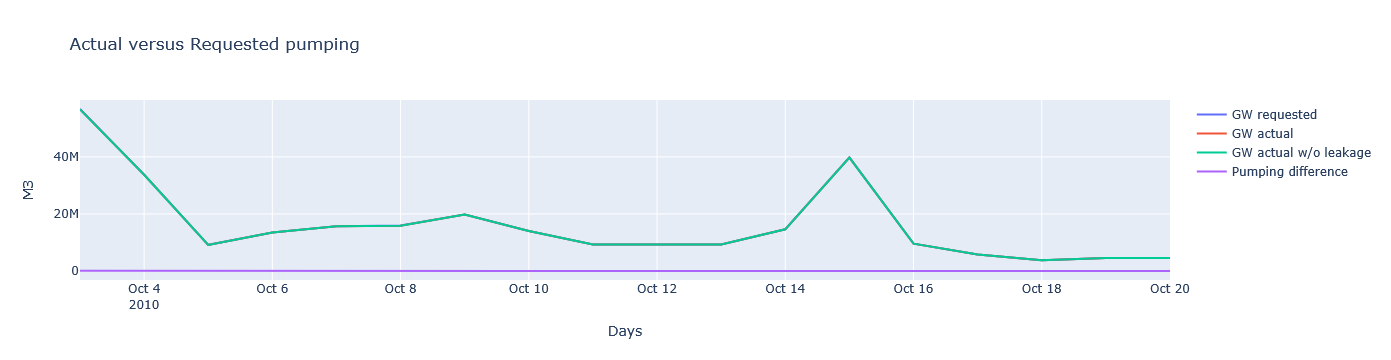

In [9]:
X = Dates_simulation
X = X[2:]

fig = go.Figure()
fig.add_trace(go.Scatter(y= Y_GWrequest,
                         x = X,
                         mode='lines',
                        name='GW requested'))
fig.add_trace(go.Scatter(y= Y_GWactual,
                         x = X,
                         mode='lines',
                        name='GW actual'))
fig.add_trace(go.Scatter(y= Y_GWactual + Y_GWleaked,
                         x = X,
                         mode='lines',
                         name = 'GW actual w/o leakage'))


fig.add_trace(go.Scatter(y= Y_GWrequest - (Y_GWactual + Y_GWleaked),
                         x = X,
                         mode='lines',
                        name='Pumping difference'))

fig.update_layout(title = 'Actual versus Requested pumping',xaxis_title = 'Days',yaxis_title = 'M3')

#fig.show()


# Overall Water Balance

In [ ]:
if text_inflow:
    inflow = []
    f = open(os.path.join(output_folder, 'inflow.tss','r'))
    for line in f.readlines()[4:]:
        inflow.append(float(line.split()[1])*86400)
    f.close()

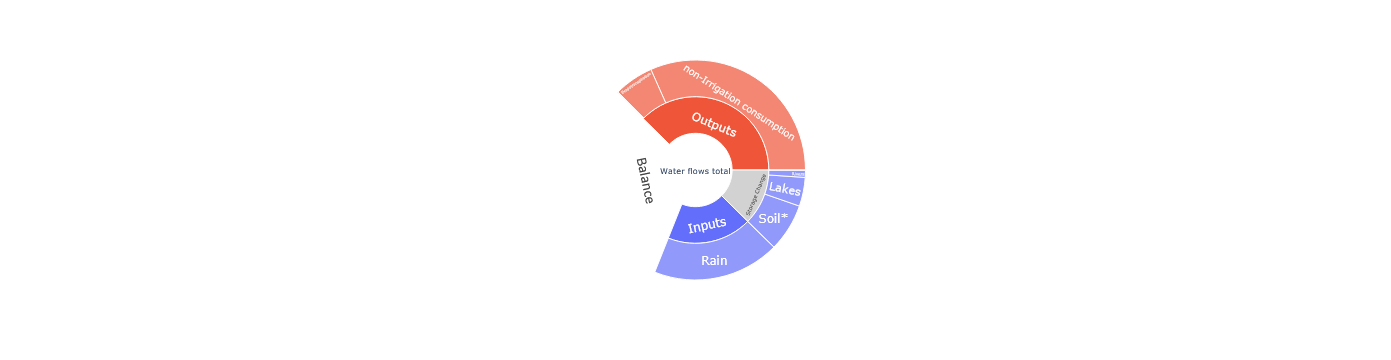

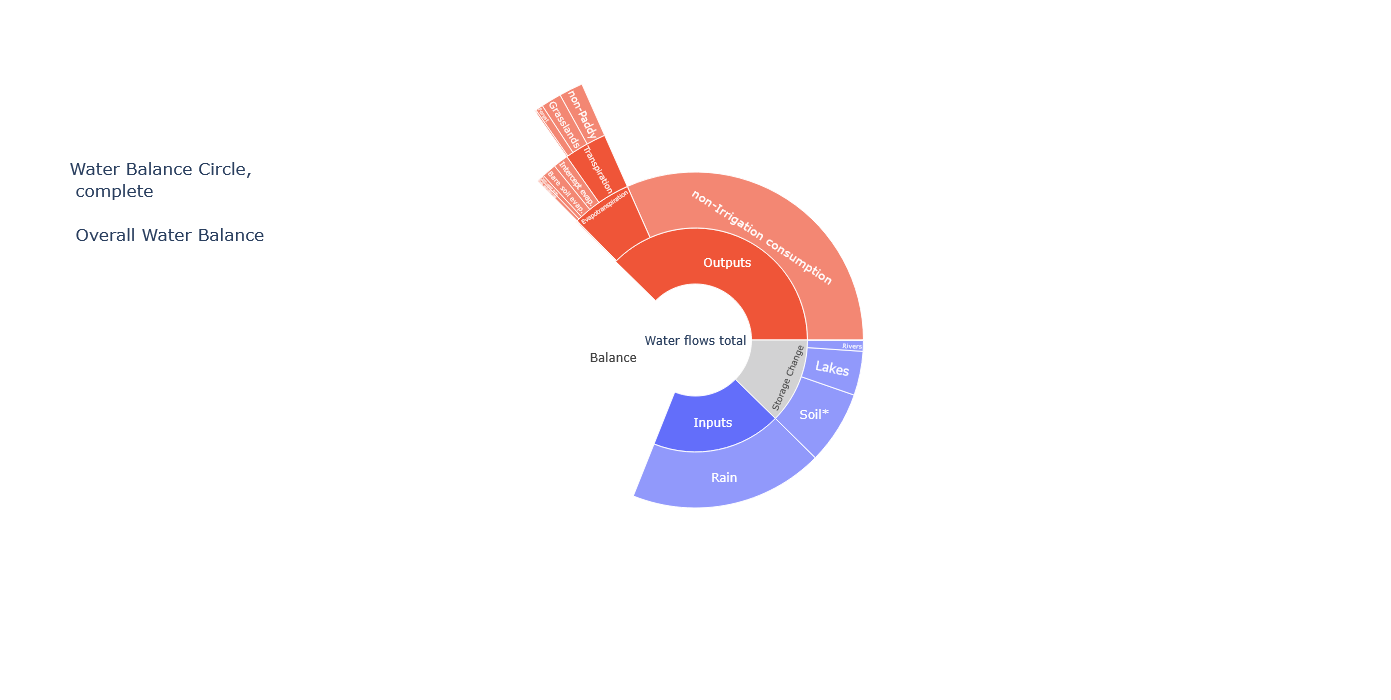

"Water flows, total",metres
Inputs,0.140
Outputs,0.282
Storage Change,0.092
Balance,0.234
Adjusted pumping,0.000
Rain,0.140
Snow,0.000
Downstream,0.000
Evapotranspiration,0.043
Channel evap.,0.000


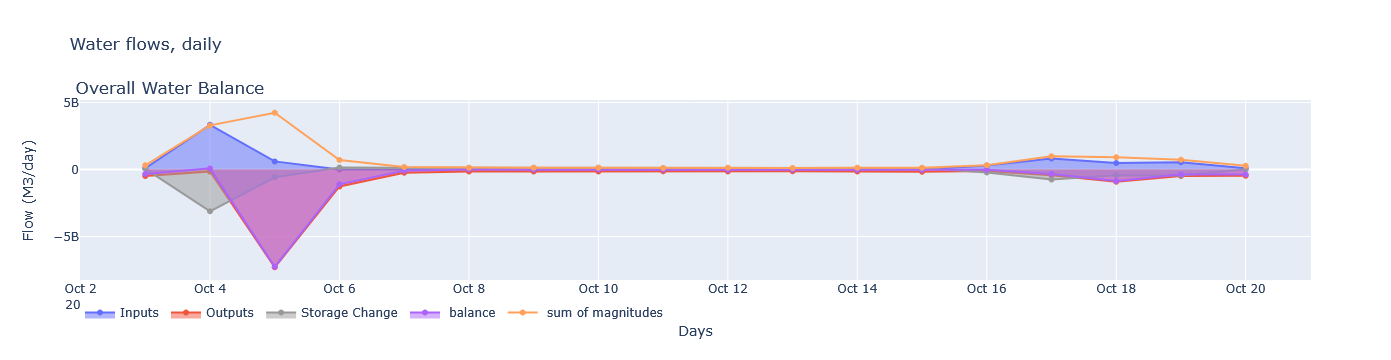

In [10]:
Figures = {}
X = Dates_simulation[2:]
Title = 'Overall Water Balance'


fig_Waterscape = go.Figure()
fig_Waterscape.update_layout(title = 'Water flows, daily: Waterscape<br><br> '+Title, xaxis_title = 'Days',yaxis_title = 'Flow (M3/day)', barmode='relative')
#fig_Waterscape.update_layout(legend_orientation="h")
Total_input, Total_output, Total_change = [],[],[]
labels_out, parents_out, values_out, colors_out = [], [], [], []
labels_simple, parents_simple, values_simple, colors_simple = [], [], [], []
Input_daily, Output_daily, Change_daily = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))

Input_current = WB['Input']
Output_current = WB['Output']
Storage_current = WB['Storage']

VARS = [[Input_current, 'Inputs', Total_input, 1, '', Input_daily], 
        [Output_current, 'Outputs', Total_output, -1, '', Output_daily], 
        [Storage_current, 'Storage', Total_change, -1, ' Change', Change_daily] ]
        #[Storage_current, 'Storage', Total_change, -1, '', Change_daily] ] #February 26

Y_select = []
for VAR in VARS:
    for Var in VAR[0]:
        
        if VAR[1] == 'Inputs' and text_inflow:
            
            Y = inflow[2:]
            
            Y_select.append([Y, 'Upstream'])
            
            VAR[5] += Y
            VAR[2].append(np.sum(Y))
            
            fig_Waterscape.add_trace(go.Bar(
                y = Y*VAR[3],
                x = X,
                name = 'Upstream'))

            labels_out.append('Upstream')
            parents_out.append(VAR[1])
            values_out.append(np.sum(Y))
            colors_out.append('positive')
            
            labels_simple.append('Upstream')
            parents_simple.append(VAR[1])
            values_simple.append(np.sum(Y))
            colors_simple.append('positive')
            
            text_inflow = False

        # Put original Y into Select chart
        Y = Var[1]
        Y = Y[2:]
        Y_select.append([Y,Var[0]])
        if Var[0] == 'Evapotranspiration':
            total_ET = np.sum(Y)
            
        if VAR[1] == 'Storage':
            
            preY = np.append(Y[0], Var[1][:-1]) 
            Y = Y - preY[2:]
            
            labels_out.append(Var[0]) # February 26 +VAR[4])
            parents_out.append(VAR[1]+VAR[4])
            values_out.append(abs(np.sum(Y)))
            colors_out.append('positive' if np.sum(Y)>0 else 'negative')
            
            
        else:
            labels_out.append(Var[0]) #+VAR[4]) February 26
            parents_out.append(VAR[1])
            values_out.append(np.sum(Y))
            colors_out.append('positive' if VAR[1] == 'Inputs' else 'negative')
            
            labels_simple.append(Var[0]+VAR[4])
            parents_simple.append(VAR[1])
            values_simple.append(np.sum(Y))
            colors_simple.append('positive' if VAR[1] == 'Inputs' else 'negative')

            
        VAR[2].append(np.sum(Y)) # Sum of a single variable, over the simulation period
        VAR[5] += Y              # The daily total sum for all variables of a type: Inputs, Outputs, Change
        
    
        fig_Waterscape.add_trace(go.Bar(
            y = Y*VAR[3],
            x = X,
            name = Var[0]+VAR[4]))

        
    line = go.Scatter(x=X, y=Y_select[0][0])
    updatemenus = [{'buttons': [{'method': 'restyle','label': i[1],'args': [{'y': [i[0]]}]} for i in Y_select], 
                    'direction': 'down', 'pad':{"r": 10, "t": 10}, 'showactive': True, 'x':0.2, 'xanchor':'left', 'y':1.225, 'yanchor':'top'}]

    layout = go.Layout(
        updatemenus=updatemenus,
        title = 'Specific flows and storages',
        xaxis_title = 'Days',
        yaxis_title = 'Volume (M3) or Flow (M3/day)')

    figure = go.Figure(data=[line], layout=layout)
    
total_input = sum(Total_input)
total_input_adjusted = total_input + Y_diffPumping
total_output = sum(Total_output)
total_change = sum(Total_change)

balance = total_input_adjusted - total_output - total_change
magnitude_change = np.sum([abs(i) for i in VARS[2][2]])

percent_accurate_WB = 100*(balance) / (0.5*total_input_adjusted + 0.5*abs(total_change) + 0.5*total_output)



#################### 
# CIRCLES
#################### 
colors_Circle_main_discrete_map={'positive':'#636EFA','negative':'#EF5538', 'white':'white', 'storage':'#D2D2D3'}
if dark:
    colors_Circle_main_discrete_map={'positive':'#636EFA','negative':'#EF5538', 'white':'black', 'storage':'#D2D2D3'}
    
values_Parents_map_Circle = {'Water flows total':total_input_adjusted+ total_output+magnitude_change+abs(balance),
                             'Inputs':total_input_adjusted, 
                             'Outputs':total_output,
                             'Storage Change':magnitude_change,
                             '':total_input_adjusted+ total_output+magnitude_change+abs(balance)                            
                            }
####################   
# Circle, main

labels_Circle_main =    ['']+['Inputs',              'Outputs',            'Storage Change',     'Balance',            'Adjusted pumping'] + labels_out  #0309

#labels_Circle_main =    ['Water flows total']+['Inputs',              'Outputs',            'Storage Change',     'Balance',            'Adjusted pumping'] + labels_out  #0225
#labels_Circle_main =    [str(10)]+['Inputs',              'Outputs',            'Storage Change',     'Balance',            'Adjusted pumping'] + labels_out 
parents_Circle_main =   ['']+['Water flows total',   'Water flows total',  'Water flows total',  'Water flows total', 'Inputs']           + parents_out
values_Circle_main =    [total_input_adjusted+ total_output+magnitude_change+abs(balance)]+[total_input_adjusted,  total_output,         magnitude_change,    abs(balance),               Y_diffPumping    ] + values_out 

values_Parents_Circle_main = ["{:.1%}".format(values_Circle_main[i]/values_Parents_map_Circle[parents_Circle_main[i]]) for i in range(len(values_Circle_main))]
#colors_Circle_main =    ['white']+['positive','negative'] +  ['positive' if total_change>0 else 'negative']+ ['positive' if balance>0 else 'negative'] + ['positive'] + colors_out
#colors_Circle_main =  ['white']+['positive','negative'] +  ['storage']+ ['positive' if balance>0 else 'negative'] + ['positive'] + colors_out
colors_Circle_main =  ['white']+['positive','negative'] +  ['storage']+ ['white'] + ['positive'] + colors_out

labels  =labels_Circle_main
parents =parents_Circle_main
values  =values_Circle_main
colors  =colors_Circle_main
fractions = values_Parents_Circle_main

d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}
#print([(labels[i], values[i]) for i in range((len(labels)))])


df = pd.DataFrame(data=d)
fig = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', branchvalues='total', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
#fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
#fig.update_layout(height=700, title='Water Balance Circle,<br> whole<br><br> '+Title)
fig.update_layout(
    title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

fig.update_layout(hoverlabel=dict(font_size=16))
if dark:
    fig.update_layout(template='plotly_dark')
fig.show()   

data_WB = {'Water flows, total':labels,'metres':[format(v/cellAreaSum,'.3f') for v in values]}
# Create DataFrame
"""
df = pd.DataFrame(data_WB)
df=df.style.set_table_styles([{'selector': 'th', 'props': [('font-size', '8pt')]}]).set_properties(**{"font-size": "8pt"}).hide(axis='index') 
display(df) 
"""

##Updating values
values  =values_Circle_main/cellAreaSum
d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}
df = pd.DataFrame(data=d)
figM = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', branchvalues='total', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
#fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
#fig.update_layout(height=700, title='Water Balance Circle,<br> whole<br><br> '+Title)
figM.update_layout(
    title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

figM.update_layout(hoverlabel=dict(font_size=16))
if dark:
    fig.update_layout(template='plotly_dark')
#figM.show() 



####################       
# Circle, glimpse

labels_Circle_simple = ['Inputs',              'Outputs',            'Storage Change',     'Balance',            'Adjusted pumping'] + labels_simple
parents_Circle_simple = ['Water flows total',   'Water flows total',  'Water flows total',  'Water flows total', 'Inputs']           + parents_simple
values_Circle_simple =  [total_input_adjusted,  total_output,         abs(total_change),    abs(balance),               Y_diffPumping    ] + values_simple
values_Parents_Circle_simple = ["{:.1%}".format(values_Circle_simple[i]/values_Parents_map_Circle[parents_Circle_main[i]]) for i in range(len(values_Circle_simple))]
#colors_Circle_simple =  ['positive','negative'] +  ['storage']+ ['positive' if balance>0 else 'negative'] + ['positive'] + colors_simple
colors_Circle_simple =  ['positive','negative'] +  ['storage']+ ['white'] + ['positive'] + colors_simple

labels  =labels_Circle_simple
parents =parents_Circle_simple
values  =values_Circle_simple
colors  =colors_Circle_simple
fractions = values_Parents_Circle_simple
d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}
df = pd.DataFrame(data=d)
fig_Circle_simple = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
fig_Circle_simple.update_layout(height=700, title='Water balance circle<br><br> '+Title)
fig_Circle_simple.update_layout(uniformtext=dict(minsize=14, mode='hide'))
fig_Circle_simple.update_layout(
    title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})
#fig_Circle_simple.show()

####################   
# Circle, main_branchvalues NOT total

labels_Circle_main =    ['Inputs',              'Outputs',            'Storage Change',     'Balance',  'Adjusted pumping'] + labels_out 
parents_Circle_main =   ['Water flows total',   'Water flows total',  'Water flows total',  'Water flows total', 'Inputs']           + parents_out
values_Circle_main =    [total_input_adjusted,  total_output,         magnitude_change,    abs(balance), Y_diffPumping] + values_out 
values_Parents_Circle_main = ["{:.1%}".format(values_Circle_main[i]/values_Parents_map_Circle[parents_Circle_main[i]]) for i in range(len(values_Circle_main))]
#colors_Circle_main =    ['white']+['positive','negative'] +  ['positive' if total_change>0 else 'negative']+ ['positive' if balance>0 else 'negative'] + ['positive'] + colors_out
#colors_Circle_main =  ['white']+['positive','negative'] +  ['storage']+ ['positive' if balance>0 else 'negative'] + colors_out
colors_Circle_main =  ['positive','negative'] +  ['storage']+ ['white', 'positive'] + colors_out

labels  =labels_Circle_main
parents =parents_Circle_main
values  =values_Circle_main
colors  =colors_Circle_main
fractions = values_Parents_Circle_main

d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}

df = pd.DataFrame(data=d)
fig_Circle_whole_v2 = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
#fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
fig_Circle_whole_v2.update_layout(height=700, title='Water balance circle<br><br> '+Title)
fig_Circle_whole_v2.update_layout(
    title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

fig_Circle_whole_v2.update_layout(hoverlabel=dict(font_size=16))
#fig_Circle_whole_v2.show() 

####################
# Circle, complete, with ET
labels_ET, parents_ET, values_ET, colors_ET = [], [], [], []
VAR = [WB['Output_ET'], 'Evapotranspiration']


for Var in VAR[0]:
    Y = Var[1]
    Y = Y[2:]
    labels_ET.append(Var[0])
    parents_ET.append(VAR[1])
    values_ET.append(np.sum(Y))
    colors_ET.append('negative')

    if Var[0] == 'Transpiration':
        total_Trans = np.sum(Y)
        
#Oct21 values_ET[-1] -= max(sum(values_ET)-total_ET, 0)


labels_Trans, parents_Trans, values_Trans, colors_Trans = [], [], [], []

VAR = [WB['Output_Trans'], 'Transpiration']

Y_select = []
for Var in VAR[0]:
    Y = Var[1]
    Y = Y[2:]
    labels_Trans.append(Var[0])
    parents_Trans.append(VAR[1])
    values_Trans.append(np.sum(Y))
    colors_Trans.append('negative')

#21Oct values_Trans[-1] -= max(sum(values_Trans)-total_Trans, 0)

values_Parents_map_Circle_complete = {'Water flows total':total_input_adjusted+ total_output+magnitude_change+abs(balance),
                             'Inputs':total_input_adjusted, 
                             'Outputs':total_output,
                             'Storage Change':magnitude_change,
                             '':total_input_adjusted+ total_output+magnitude_change+abs(balance),
                             'Evapotranspiration': total_ET,
                             'Transpiration':total_Trans
                            }


labels  =labels_Circle_main+labels_ET+labels_Trans
parents =parents_Circle_main+ parents_ET+ parents_Trans
values  =values_Circle_main+values_ET+values_Trans
colors  =colors_Circle_main+ colors_ET+ colors_Trans
fractions = ["{:.1%}".format(values[i]/values_Parents_map_Circle_complete[parents[i]]) for i in range(len(values))]

d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}

df = pd.DataFrame(data=d)
fig_Circle_complete = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', branchvalues='total', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
#fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
fig_Circle_complete.update_layout(height=700, title='Water balance circle<br><br> '+Title)
fig_Circle_complete.update_layout(
    title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

fig_Circle_complete.update_layout(hoverlabel=dict(font_size=16))
if dark:
    fig_Circle_complete.update_layout(template='plotly_dark')
fig_Circle_complete.show()

# Creating circle with crops
# ['actTransTotal_crops_Irr[0]', 'Trans Irr crop 0', 'M', 'Output_irrTrans']
data_WB = {'Water flows, total':labels,'metres':[format(v/cellAreaSum,'.3f') for v in values]}
# Create DataFrame
df = pd.DataFrame(data_WB)
df=df.style.set_table_styles([{'selector': 'th', 'props': [('font-size', '8pt')]}]).set_properties(**{"font-size": "8pt"}).hide(axis='index') 
display(df) 



####################
# Waterscape, Bar chart, daily water flows

fig_Waterscape.update_traces(marker=dict(colorscale='twilight'))
#fig_Waterscape.show()

# Bar chart, total, water balance

Bar_WB=go.Figure(go.Bar(x=['Inputs', 'Outputs', 'Storage Change', 'Water balance'], y=[total_input_adjusted, total_output, abs(total_change), balance],marker=dict(color=['#636EFA', '#EF5538','#00CC96','white'])))
Bar_WB.update_layout(title = 'Water flows, total<br><br> '+Title,
                  yaxis_title = 'Total Flow (M3/simulation) ')
#Bar_WB.update_layout(legend_orientation="h")

#VARS = [[Input_current, 'Inputs', Total_input, 1, '', Input_daily], 
#        [Output_current, 'Outputs', Total_output, -1, '', Output_daily], 
#        [Storage_current, 'Storage', Total_change, -1, ' Change', Change_daily] ]
# Line graph, and lines on Water Balance, waterscape
Line_WB = go.Figure()
Line_WB.update_layout(title = 'Water flows, daily<br><br> '+Title, xaxis_title = 'Days',yaxis_title = 'Flow (M3/day)')
for VAR in VARS:
    

    
    # Waterscape Bar chart, adding lines
    if VAR[1] == 'Inputs':
        color = '#636EFA'
    if VAR[1] == 'Outputs':
        color = '#EF553B'
    if VAR[1] == 'Storage':
        color = '#999999'
        
        # Waterscape Line graph
    Line_WB.add_trace(go.Scatter(x=X, y=VAR[3]*VAR[5], fill='tozeroy', name=VAR[1]+VAR[4], line=dict(color=color)))
    
    fig_Waterscape.add_trace(go.Scatter(x=X, y=VAR[3]*VAR[5], name=VAR[1]+VAR[4], line=dict(color=color))) #,  #visible='legendonly')) {'positive':'rgb(128,177,211)','negative':'#EF5538', 'white':'white'}
Line_WB.add_trace(go.Scatter(x=X, y=VARS[0][3]*VARS[0][5] + VARS[1][3]*VARS[1][5] + VARS[2][3]*VARS[2][5], fill='tozeroy', name= ' balance'))    
Line_WB.add_trace(go.Scatter(x=X, y=(abs(VARS[0][3]*VARS[0][5]) + abs(VARS[1][3]*VARS[1][5]) + abs(VARS[2][3]*VARS[2][5]))*.5,  name= ' sum of magnitudes'))    
####################  
# Table
# intialise data of lists.
data_WB = {'Water flows, total':['Inputs', 'Outputs', 'Storage Change', 'Balance', 'Balance over all flows (%):'],'BMC':[  total_input_adjusted/1_000_000_000,   total_output/1_000_000_000,   total_change/1_000_000_000,   balance/1_000_000_000, percent_accurate_WB]}
# Create DataFrame
df = pd.DataFrame(data_WB)
df=df.style.set_table_styles([{'selector': 'th', 'props': [('font-size', '15pt')]}]).set_properties(**{"font-size": "15pt"}).hide(axis='index') 
    
####################   
# Print examples.
#fig_Circle_simple.show()
#fig.show()
#fig_Circle_whole_v2.show() 
#fig_Circle_complete.show()
#fig_Waterscape.show()
#Bar_WB.show()
if dark:
    Line_WB.update_layout(template='plotly_dark')
    fig_Waterscape.update_layout(template='plotly_dark')
    figure.update_layout(template='plotly_dark')
Line_WB.update_layout(legend_orientation="h")
Line_WB.show()
#display(df)

Figures['fig_Circle_simple_']= fig_Circle_simple
Figures['fig_']= fig
Figures['fig_Circle_whole_v2_']= fig_Circle_whole_v2
Figures['Line_WB_']= Line_WB

Figures['fig_Waterscape_']= fig_Waterscape
Figures['Bar_WB_']= Bar_WB
Figures['df_']= df
Figures['figure_']= figure



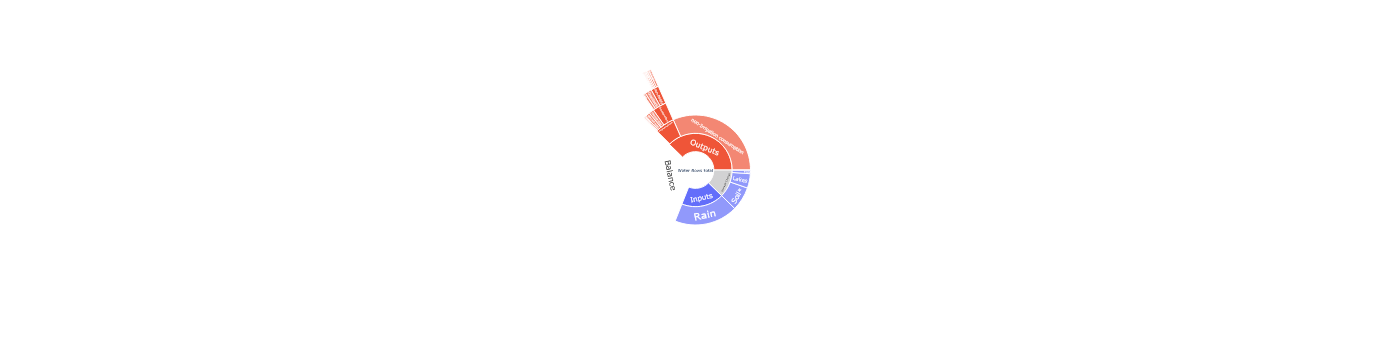

In [11]:
if withCrops == True:
    ####################
    # Circle, complete, with ET
    #['sum_actTransTotal',       'Transpiration',                'M',    'Output_ET'],
    labels_ET, parents_ET, values_ET, colors_ET = [], [], [], []
    VAR = [WB['Output_ET'], 'Evapotranspiration']


    for Var in VAR[0]:
        Y = Var[1]
        Y = Y[2:]
        labels_ET.append(Var[0])
        parents_ET.append(VAR[1])
        values_ET.append(np.sum(Y))
        colors_ET.append('negative')

        if Var[0] == 'Transpiration':
            total_Trans = np.sum(Y)

    #21Oct values_ET[-1] += max(sum(values_ET)-total_ET, 0)

    ####
    # ['actTransTotal_nonpaddy', 'Transpiration (non-Paddy)', 'M', 'Output_Trans']
    labels_Trans, parents_Trans, values_Trans, colors_Trans = [], [], [], []

    VAR = [WB['Output_Trans'], 'Transpiration']

    #21Oct Y_select = []
    for Var in VAR[0]:
        Y = Var[1]
        Y = Y[2:]
        labels_Trans.append(Var[0])
        parents_Trans.append(VAR[1])
        values_Trans.append(np.sum(Y))
        colors_Trans.append('negative')

        if Var[0] == 'non-Paddy': #21Oct Transpiration (non-Paddy)
            total_irrTrans = np.sum(Y)    
        if Var[0] == 'Grasslands': #21Oct Transpiration (non-Paddy)
            total_nonirrTrans = np.sum(Y)    

    #Oct21 values_Trans[-1] += max(sum(values_Trans)-total_Trans, 0)
    #####
    # ['actTransTotal_crops_Irr[0]', 'Trans Irr crop 0', 'M', 'Output_irrTrans']
    labels_irrTrans, parents_irrTrans, values_irrTrans, colors_irrTrans = [], [], [], []
    if 'Output_irrTrans' in WB.keys():
        
        VAR = [WB['Output_irrTrans'], 'non-Paddy']
        for Var in VAR[0]:
            Y = Var[1]
            Y = Y[2:]
            labels_irrTrans.append(Var[0])
            parents_irrTrans.append(VAR[1])
            values_irrTrans.append(np.sum(Y))
            colors_irrTrans.append('negative')
        
    
    labels_nonirrTrans, parents_nonirrTrans, values_nonirrTrans, colors_nonirrTrans = [], [], [], []
    if 'Output_nonirrTrans' in WB.keys():
        
        VAR = [WB['Output_nonirrTrans'], 'Grasslands']
        for Var in VAR[0]:
            Y = Var[1]
            Y = Y[2:]
            labels_irrTrans.append(Var[0])
            parents_irrTrans.append(VAR[1])
            values_irrTrans.append(np.sum(Y))
            colors_irrTrans.append('negative')

    #21Oct values_irrTrans[-1] -= max(sum(values_irrTrans)-total_irrTrans, 0)

    values_Parents_map_Circle_complete = {'Water flows total':total_input_adjusted+ total_output+magnitude_change+abs(balance),
                                          'Inputs':total_input_adjusted, 
                                          'Outputs':total_output, 
                                          'Storage Change':magnitude_change,
                                          '':total_input_adjusted+ total_output+magnitude_change+abs(balance), 
                                          'Evapotranspiration': total_ET,   
                                          'Transpiration':total_Trans,
                                          'non-Paddy': total_irrTrans,
                                          'Grasslands': total_nonirrTrans
                                }


    labels  =labels_Circle_main+labels_ET+labels_Trans+labels_irrTrans+labels_nonirrTrans
    parents =parents_Circle_main+ parents_ET+ parents_Trans + parents_irrTrans+ parents_nonirrTrans
    values  =values_Circle_main+values_ET+values_Trans + values_irrTrans + values_nonirrTrans
    colors  =colors_Circle_main+ colors_ET+ colors_Trans + colors_irrTrans + colors_nonirrTrans
    fractions = ["{:.1%}".format(values[i]/values_Parents_map_Circle_complete[parents[i]]) for i in range(len(values))]

    #print([(labels[i], values[i]) for i in range((len(labels)))])

    d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}

    df = pd.DataFrame(data=d)
    fig_Circle_complete_crops = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', branchvalues='total', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
    #fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
    fig_Circle_complete.update_layout(height=700, title='Water balance circle<br><br> '+Title)
    fig_Circle_complete.update_layout(
        title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

    fig_Circle_complete_crops.update_layout(hoverlabel=dict(font_size=16))
    if dark:
        fig_Circle_complete_crops.update_layout(template='plotly_dark')
    fig_Circle_complete_crops.show()


    # Creating circle with crops 
    # ['actTransTotal_crops_Irr[0]', 'Trans Irr crop 0', 'M', 'Output_irrTrans']



# Try all specific balances

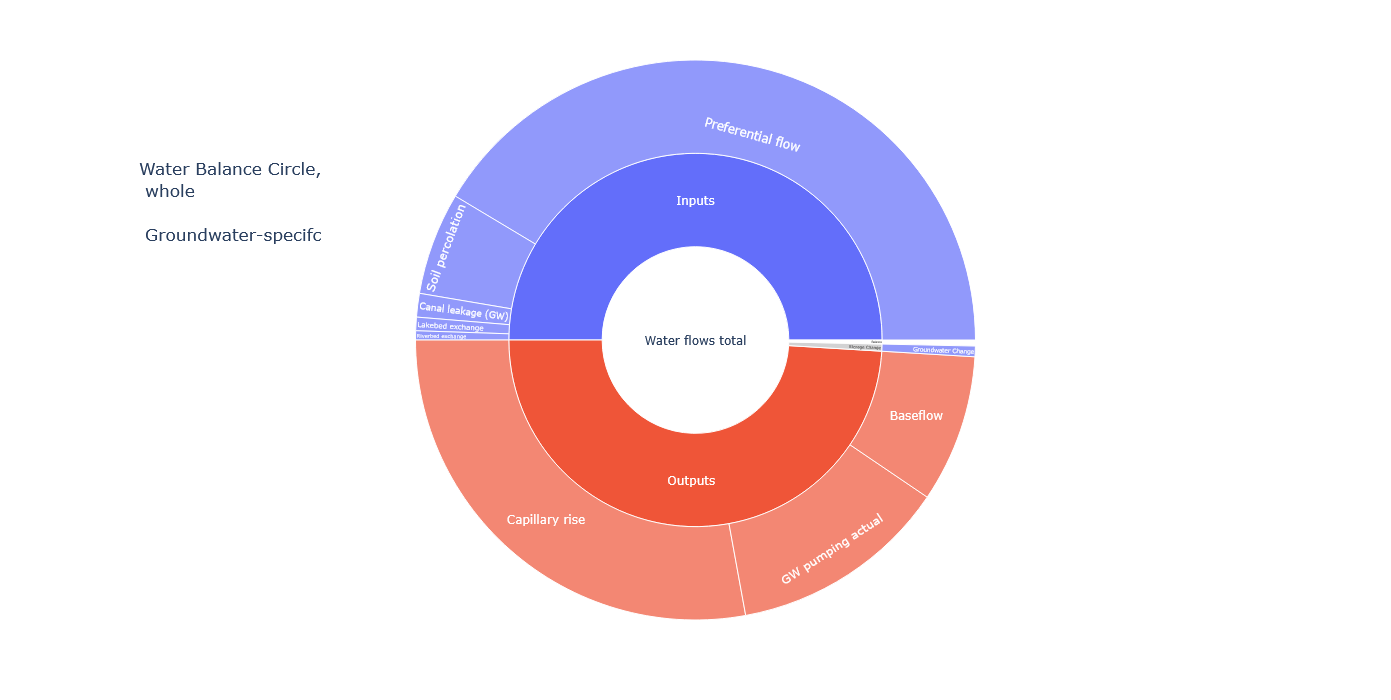

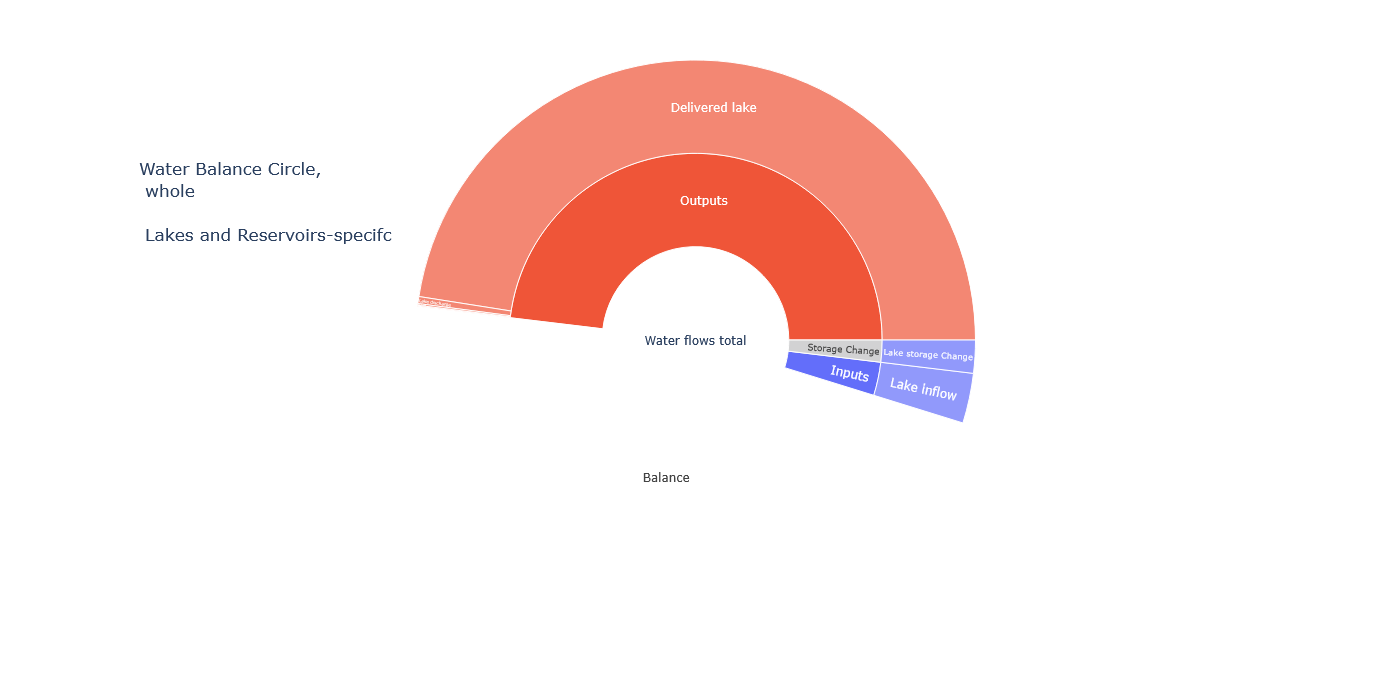

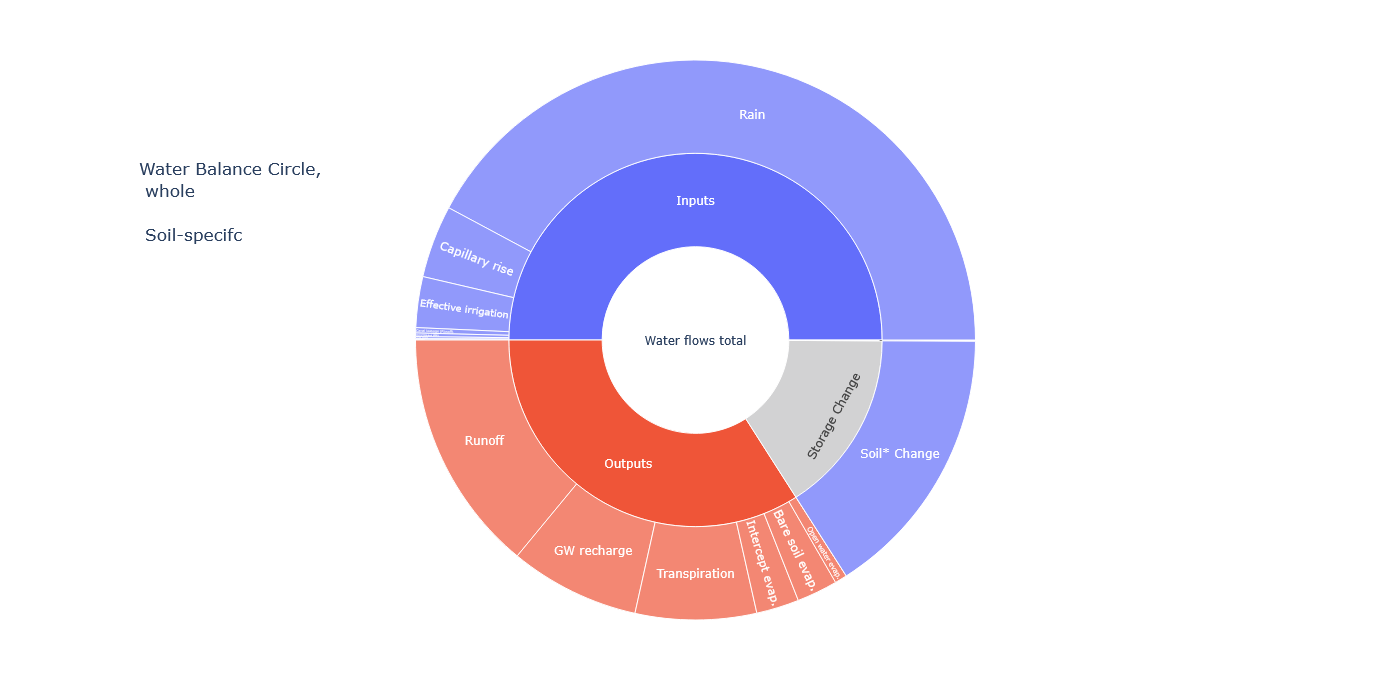

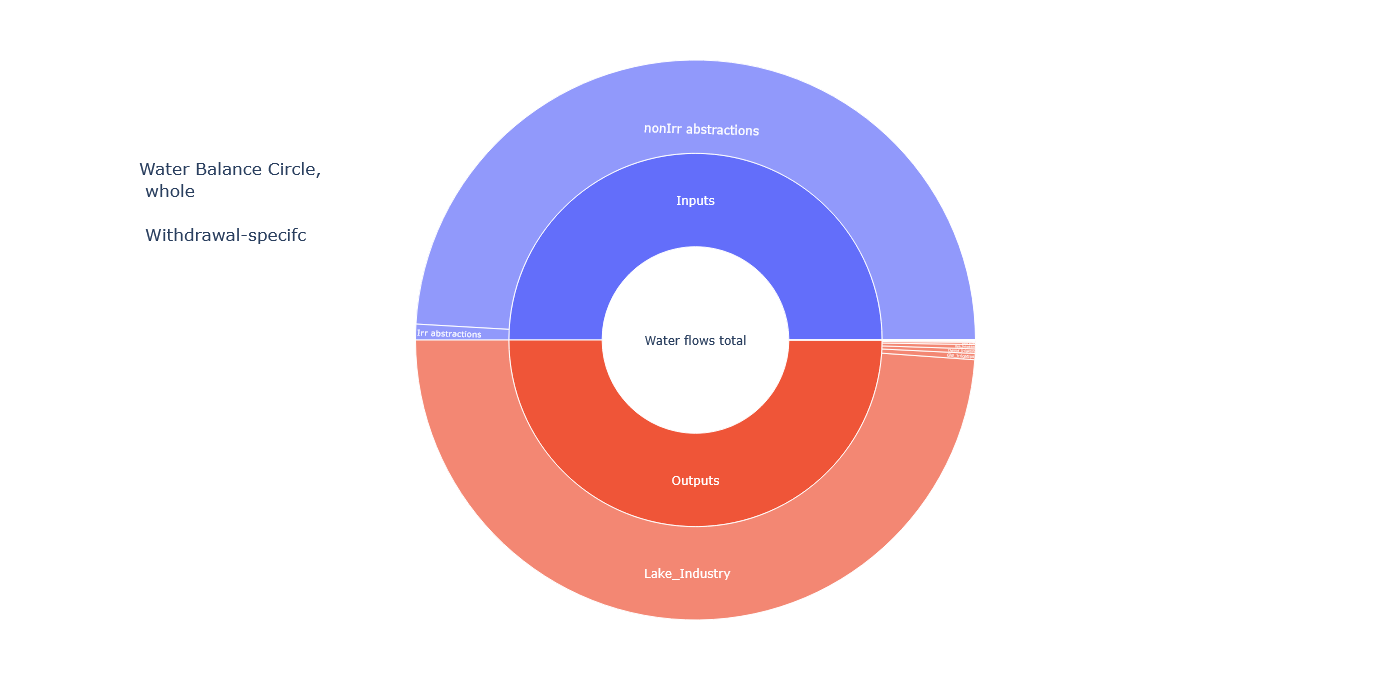

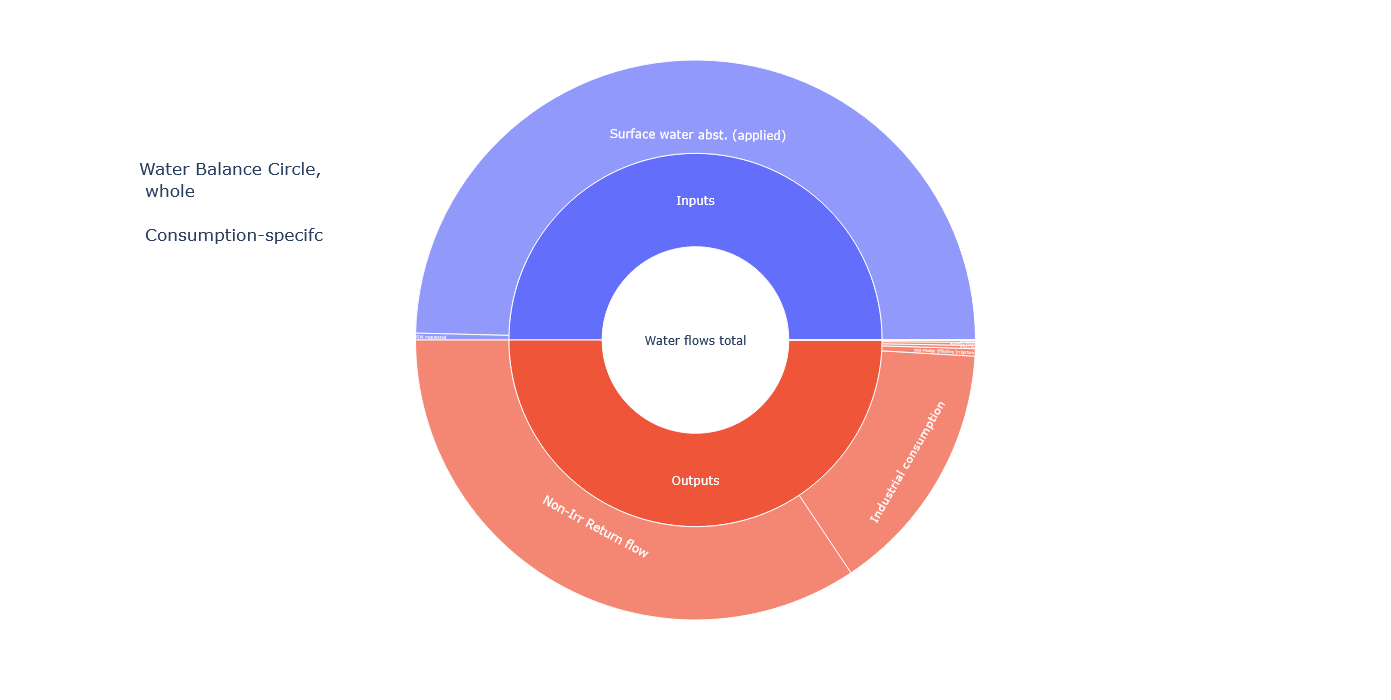

In [12]:
WB['Storage_Consumption']=[]
WB['Storage_Withdrawal']=[]
"""
if not consumption:
    WB['Input_Consumption']=[]
    WB['Storage_Consumption']=[]
    WB['Output_Consumption']=[]
    
if not withdrawals:
    WB['Input_Withdrawal']=[]
    WB['Storage_Withdrawal']=[]
    WB['Output_Withdrawal']=[]
"""

Sections = [['Groundwater', WB['Input_GW'], WB['Output_GW'], WB['Storage_GW']], 
                ['Lakes and Reservoirs', WB['Input_LR'], WB['Output_LR'], WB['Storage_LR']],
                ['Soil', WB['Input_Soil'], WB['Output_Soil'], WB['Storage_Soil']]]

if withdrawals:
    Sections.extend([['Withdrawal', WB['Input_Withdrawal'], WB['Output_Withdrawal'], WB['Storage_Withdrawal']]])
                     
if consumption:
    Sections.extend([['Consumption', WB['Input_Consumption'], WB['Output_Consumption'], WB['Storage_Consumption']]])

for section in Sections:

    Title = section[0]+'-specifc'

    Input_current = section[1] #WB['Input_LR']
    Output_current = section[2]#WB['Output_LR']
    Storage_current = section[3]#WB['Storage_LR']

    X = Dates_simulation[2:]
    fig_Waterscape = go.Figure()
    fig_Waterscape.update_layout(title = 'Water flows, daily: Waterscape<br><br> '+Title, xaxis_title = 'Days',yaxis_title = 'Flow (M3/day)', barmode='relative')

    Total_input, Total_output, Total_change = [],[],[]
    labels_out, parents_out, values_out, colors_out = [], [], [], []
    labels_simple, parents_simple, values_simple, colors_simple = [], [], [], []
    Input_daily, Output_daily, Change_daily = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))



    VARS = [[Input_current, 'Inputs', Total_input, 1, '', Input_daily], 
            [Output_current, 'Outputs', Total_output, -1, '', Output_daily], 
            [Storage_current, 'Storage', Total_change, -1, ' Change', Change_daily] ]

    Y_select = []
    for VAR in VARS:
        for Var in VAR[0]:

            if Var[0]=='GW pumping actual':
               
                Y = Y_GWactual + Y_GWleaked
            else:
                # Put original Y into Select chart
                Y = Var[1]
                Y = Y[2:]

            Y_select.append([Y,Var[0]])

            if VAR[1] == 'Storage':

                preY = np.append(Y[0], Var[1][:-1]) 
                Y = Y - preY[2:]

                labels_out.append(Var[0]+VAR[4])
                parents_out.append(VAR[1]+VAR[4])
                values_out.append(abs(np.sum(Y)))
                colors_out.append('positive' if np.sum(Y)>0 else 'negative')


            else:
                labels_out.append(Var[0]+VAR[4])
                parents_out.append(VAR[1])
                values_out.append(np.sum(Y))
                colors_out.append('positive' if VAR[1] == 'Inputs' else 'negative')

                labels_simple.append(Var[0]+VAR[4])
                parents_simple.append(VAR[1])
                values_simple.append(np.sum(Y))
                colors_simple.append('positive' if VAR[1] == 'Inputs' else 'negative')


            VAR[2].append(np.sum(Y)) # Sum of a single variable, over the simulation period
            VAR[5] += Y              # The daily total sum for all variables of a type: Inputs, Outputs, Change


            fig_Waterscape.add_trace(go.Bar(
                y = Y*VAR[3],
                x = X,
                name = Var[0]+VAR[4]))

        if Y_select != []:
            line = go.Scatter(x=X, y=Y_select[0][0])
            updatemenus = [{'buttons': [{'method': 'restyle','label': i[1],'args': [{'y': [i[0]]}]} for i in Y_select], 
                            'direction': 'down', 'pad':{"r": 10, "t": 10}, 'showactive': True, 'x':0.2, 'xanchor':'left', 'y':1.225, 'yanchor':'top'}]

            layout = go.Layout(
                updatemenus=updatemenus,
                title = 'Specific flows and storages',
                xaxis_title = 'Days',
                yaxis_title = 'Volume (M3) or Flow (M3/day)')

            figure = go.Figure(data=[line], layout=layout)

    total_input = sum(Total_input)
    total_input_adjusted = total_input #+ Y_diffPumping
    total_output = sum(Total_output)
    total_change = sum(Total_change)

    balance = total_input_adjusted - total_output - total_change
    magnitude_change = np.sum([abs(i) for i in VARS[2][2]])

    percent_accurate_WB = 100*(balance) / (0.5*total_input_adjusted + 0.5*abs(total_change) + 0.5*total_output)



    #################### 
    # CIRCLES
    #################### 
    colors_Circle_main_discrete_map={'positive':'#636EFA','negative':'#EF5538', 'white':'white', 'storage':'#D2D2D3'}
    if dark:
        colors_Circle_main_discrete_map={'positive':'#636EFA','negative':'#EF5538', 'white':'black', 'storage':'#D2D2D3'}
    values_Parents_map_Circle = {'Water flows total':total_input_adjusted+ total_output+magnitude_change+abs(balance),
                                 'Inputs':total_input_adjusted, 
                                 'Outputs':total_output,
                                 'Storage Change':magnitude_change,
                                 '':total_input_adjusted+ total_output+magnitude_change+abs(balance)                            
                                }
    ####################   
    # Circle, main

    #labels_Circle_main =    ['Water flows total']+['Inputs',              'Outputs',            'Storage Change',     'Balance'] + labels_out #March9
    labels_Circle_main =    ['']+['Inputs',              'Outputs',            'Storage Change',     'Balance'] + labels_out 
    parents_Circle_main =   ['']+['Water flows total',   'Water flows total',  'Water flows total',  'Water flows total']           + parents_out
    values_Circle_main =    [total_input_adjusted+ total_output+magnitude_change+abs(balance)]+[total_input_adjusted,  total_output,         magnitude_change,    abs(balance)] + values_out 
    values_Parents_Circle_main = ["{:.1%}".format(values_Circle_main[i]/values_Parents_map_Circle[parents_Circle_main[i]]) for i in range(len(values_Circle_main))]
    #colors_Circle_main =    ['white']+['positive','negative'] +  ['positive' if total_change>0 else 'negative']+ ['positive' if balance>0 else 'negative'] + ['positive'] + colors_out
    #colors_Circle_main =  ['white']+['positive','negative'] +  ['storage']+ ['positive' if balance>0 else 'negative'] + colors_out
    if dark:
        colors_Circle_main =  ['black']+['positive','negative'] +  ['storage']+ ['white'] + colors_out
    else:
        colors_Circle_main =  ['white']+['positive','negative'] +  ['storage']+ ['white'] + colors_out

    labels  =labels_Circle_main
    parents =parents_Circle_main
    values  =values_Circle_main
    colors  =colors_Circle_main
    fractions = values_Parents_Circle_main
    

    d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}
    df = pd.DataFrame(data=d)
    fig = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', branchvalues='total', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
    
    #fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
    fig.update_layout(height=700, title='Water Balance Circle,<br> whole<br><br> '+Title)
    fig.update_layout(
        title={'y':0.75, 'x':0.1, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

    fig.update_layout(hoverlabel=dict(font_size=16))
    if dark:
        fig.update_layout(template='plotly_dark')
    fig.show()        

    ####################       
    # Circle, simplified

    labels_Circle_simple = ['Inputs',              'Outputs',            'Storage Change',     'Balance'] + labels_simple
    parents_Circle_simple = ['Water flows total',   'Water flows total',  'Water flows total',  'Water flows total']           + parents_simple
    values_Circle_simple =  [total_input_adjusted,  total_output,         abs(total_change),    abs(balance)] + values_simple
    values_Parents_Circle_simple = ["{:.1%}".format(values_Circle_simple[i]/values_Parents_map_Circle[parents_Circle_main[i]]) for i in range(len(values_Circle_simple))]
    #colors_Circle_simple =  ['positive','negative'] +  ['storage']+ ['positive' if balance>0 else 'negative']+ colors_simple
    colors_Circle_simple =  ['positive','negative'] +  ['storage']+ ['white']+ colors_simple

    labels  =labels_Circle_simple
    parents =parents_Circle_simple
    values  =values_Circle_simple
    colors  =colors_Circle_simple
    fractions = values_Parents_Circle_simple
    
    
    d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}
    df = pd.DataFrame(data=d)
    fig_Circle_simple = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
    
    fig_Circle_simple.update_layout(height=700, title='Water alance Circle,<br> glimpse<br><br> '+Title)
    #fig_Circle_simple.update_layout(uniformtext=dict(minsize=14, mode='hide'))
    fig_Circle_simple.update_layout(
        title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})
    #fig_Circle_simple.show()

    ####################   
    # Circle, main_branchvalues NOT total

    labels_Circle_main =    ['Inputs',              'Outputs',            'Storage Change',     'Balance'] + labels_out 
    parents_Circle_main =   ['Water flows total',   'Water flows total',  'Water flows total',  'Water flows total']           + parents_out
    values_Circle_main =    [total_input_adjusted,  total_output,         magnitude_change,    abs(balance)] + values_out 
    values_Parents_Circle_main = ["{:.1%}".format(values_Circle_main[i]/values_Parents_map_Circle[parents_Circle_main[i]]) for i in range(len(values_Circle_main))]
    #colors_Circle_main =    ['white']+['positive','negative'] +  ['positive' if total_change>0 else 'negative']+ ['positive' if balance>0 else 'negative'] + ['positive'] + colors_out
    #colors_Circle_main =  ['white']+['positive','negative'] +  ['storage']+ ['positive' if balance>0 else 'negative'] + colors_out
    colors_Circle_main =  ['positive','negative'] +  ['storage']+ ['white'] + colors_out

    labels  =labels_Circle_main
    parents =parents_Circle_main
    values  =values_Circle_main
    colors  =colors_Circle_main
    fractions = values_Parents_Circle_main
    

    d={'labels':labels, 'parents':parents, 'values':values, 'colors':colors, 'fractions':fractions}

    df = pd.DataFrame(data=d)
    fig_Circle_whole_v2 = px.sunburst(df, names='labels', parents='parents', values='values', color='colors', color_discrete_map=colors_Circle_main_discrete_map, hover_data=['fractions'])
    fig.update_layout(uniformtext=dict(minsize=15, mode='hide'))
    fig_Circle_whole_v2.update_layout(height=700, title='Water Balance Circle,<br> whole v2<br><br> '+Title)
    fig_Circle_whole_v2.update_layout(
        title={'y':0.75, 'x':0.05, 'xanchor': 'left', 'yanchor': 'top'}) #, 'font_size':26})

    fig_Circle_whole_v2.update_layout(hoverlabel=dict(font_size=16))
    #fig_Circle_whole_v2.show()   

    ####################
    # Waterscape, Bar chart, daily water flows

    fig_Waterscape.update_traces(marker=dict(colorscale='twilight'))
    #fig_Waterscape.show()

    # Bar chart, total, water balance

    Bar_WB=go.Figure(go.Bar(x=['Inputs', 'Outputs', 'Storage Change', 'Water balance'], y=[total_input_adjusted, total_output, abs(total_change), balance],marker=dict(color=['#636EFA', '#EF5538','#00CC96','white'])))
    Bar_WB.update_layout(title = 'Water flows, total<br><br> '+Title,
                      yaxis_title = 'Total Flow (M3/simulation) ')

    #VARS = [[Input_current, 'Inputs', Total_input, 1, '', Input_daily], 
    #        [Output_current, 'Outputs', Total_output, -1, '', Output_daily], 
    #        [Storage_current, 'Storage', Total_change, -1, ' Change', Change_daily] ]
    # Line graph, and lines on Water Balance, waterscape
    Line_WB = go.Figure()
    Line_WB.update_layout(title = 'Water flows, daily<br><br> '+Title, xaxis_title = 'Days',yaxis_title = 'Flow (M3/day)')

    for VAR in VARS:

        # Waterscape Line graph
        

        # Waterscape Bar chart, adding lines
        if VAR[1] == 'Inputs':
            color = '#636EFA'
        if VAR[1] == 'Outputs':
            color = '#EF553B'
        if VAR[1] == 'Storage':
            color = '#999999' #'#00CC96'
            
        Line_WB.add_trace(go.Scatter(x=X, y=VAR[3]*VAR[5], fill='tozeroy', name=VAR[1]+VAR[4], line=dict(color=color)))

        fig_Waterscape.add_trace(go.Scatter(x=X, y=VAR[3]*VAR[5], name=VAR[1]+VAR[4], line=dict(color=color))) #,  #visible='legendonly')) {'positive':'rgb(128,177,211)','negative':'#EF5538', 'white':'white'}
    Line_WB.add_trace(go.Scatter(x=X, y=VARS[0][3]*VARS[0][5] + VARS[1][3]*VARS[1][5] + VARS[2][3]*VARS[2][5], fill='tozeroy', name= ' balance'))    
    fig_Waterscape.add_trace(go.Scatter(x=X, y=VARS[0][3]*VARS[0][5] + VARS[1][3]*VARS[1][5] + VARS[2][3]*VARS[2][5], name= ' balance'))    
    #fig_Waterscape.update_layout(legend_orientation="h")
    ####################  
    # Table
    # intialise data of lists.
    data_WB = {'Water flows, total: '+Title:['Inputs', 'Outputs', 'Storage Change', 'Balance', 'Balance over all flows (%):'],'BMC':[  total_input_adjusted/1_000_000_000,   total_output/1_000_000_000,   total_change/1_000_000_000,   balance/1_000_000_000, percent_accurate_WB]}
    # Create DataFrame
    df = pd.DataFrame(data_WB)
    # March24 df=df.style.set_table_styles([{'selector': 'th', 'props': [('font-size', '15pt')]}]).set_properties(**{"font-size": "15pt"}).hide_index()
    df=df.style.set_table_styles([{'selector': 'th', 'props': [('font-size', '15pt')]}]).set_properties(**{"font-size": "15pt"}).hide(axis='index')



    ####################   
    # Print examples.
    #fig_Circle_simple.show()
    #fig.show()
    #fig_Circle_whole_v2.show() 
    #Line_WB.show()
    #fig_Waterscape.show()
    #Bar_WB.show()
    #display(df)
    #po.iplot(figure)
    if dark:
        fig_Waterscape.update_layout(template='plotly_dark')

    Figures['fig_Circle_simple_'+section[0]]= fig_Circle_simple
    Figures['fig_'+section[0]]= fig
    Figures['fig_Circle_whole_v2_'+section[0]]= fig_Circle_whole_v2
    Figures['Line_WB_'+section[0]]= Line_WB
    
    Figures['fig_Waterscape_'+section[0]]= fig_Waterscape
    Figures['Bar_WB_'+section[0]]= Bar_WB
    Figures['df_'+section[0]]= df
    Figures['figure_'+section[0]]= figure
    

# Water balance

A water balance is used to understand the different flows through a system. The inputs to the system should equal the outputs from the system plus whatever stayed in the system. The water balance is an application of the conservation of mass.

$\text{Inputs} - \left(\text{Outputs} +\Delta\text{Storage}\right) = 0$


## Water balance circle

The water balance is illustrated below in a sunburst pie chart. If the water balance circle is closed (no blank spaces), then the water balanace is also closed. The dominant inputs and outputs of the system are labelled, while the other variables and their values are seen by hovering the cursor over the smaller slices.

## Water balance: Bar chart and Table

The total water balance visualised with the water balance circle presented above, is presented here as a bar chart and table.

The Balance over all flows (%) entry in the table is the following calculation: $\frac{\text{Inputs} - \left(\text{Outputs} +\Delta\text{Storage}\right)}{\frac{1}{2} \left(\text{Inputs} + \text{Outputs} +\Delta\text{Storage}\right)}*100$



## Water balance waterscape: daily fluxes

In this Water balance waterscape, the inputs are positive, while the outputs and increases in storage are negative. If the water balance is closed, the area of the top half of the graph should equal that of the bottom half.

The different flows can be visulised in different combinations: 
- Deselect flows to visualise by clicking on their legend entry.
- A single flow can be isolated by double clicking on the legend entry, and double-clicking a single entry includes all the flows in the visulaistion.
- Graphs showing the total inputs, outputs, and changes in storage daily can be visualised by activating the the Inputs, Outputs, and Change in Storage entries in the legend. These are initially turned off.

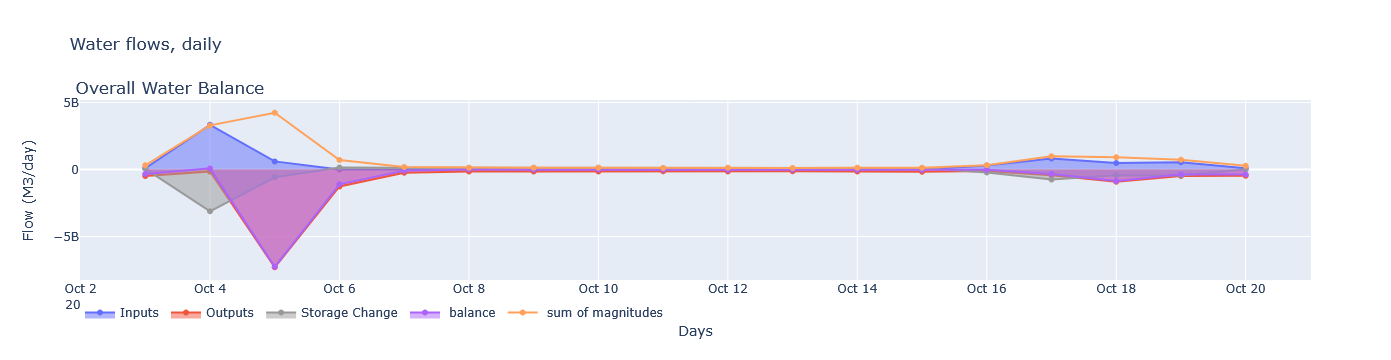

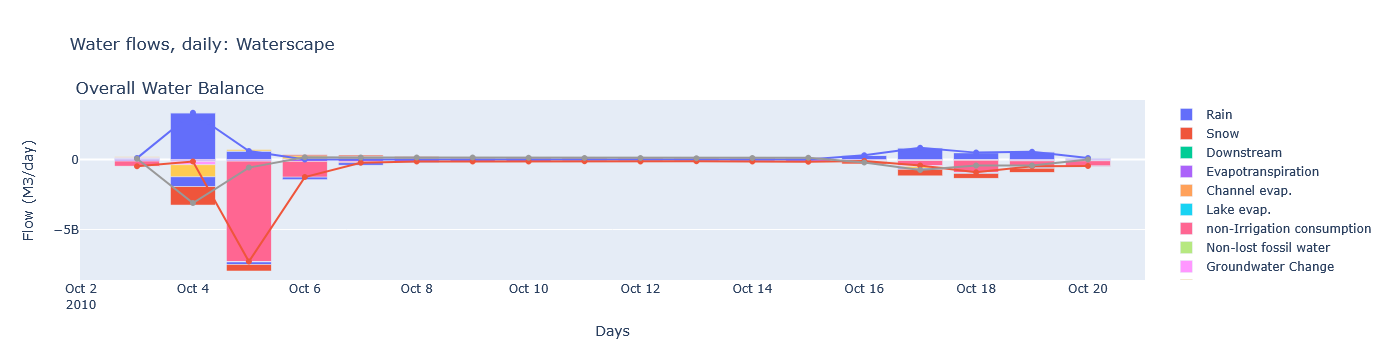

In [13]:
Figures['Line_WB_'].show()
Figures['fig_Waterscape_'].show()


## Specific flows and storages

The specific flow and storage variables used in CWatM related to this water balance can be visualised over the simulation period. 

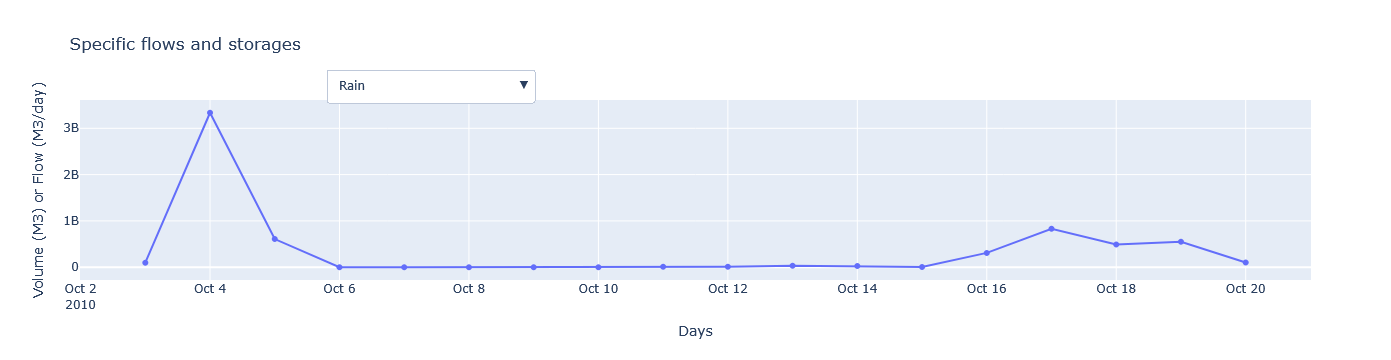

In [14]:
#po.init_notebook_mode() 

po.iplot(Figures['figure_'])

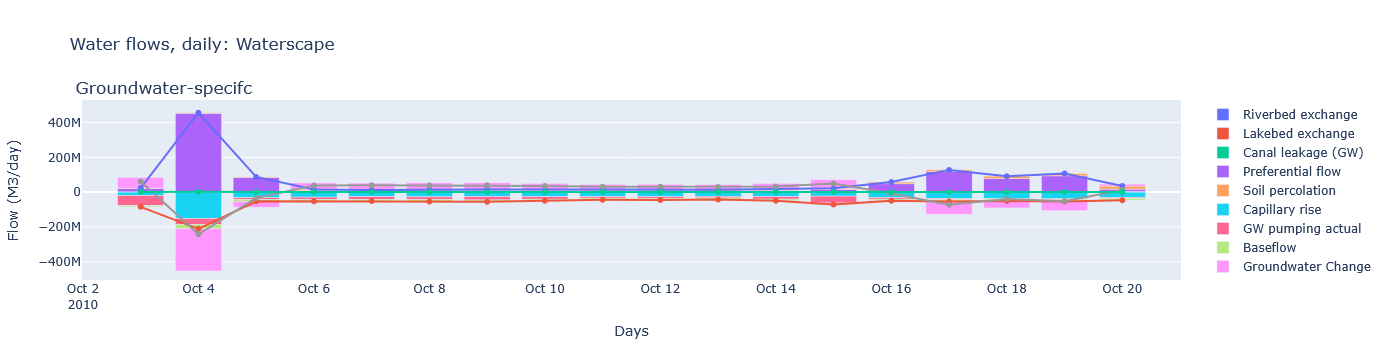

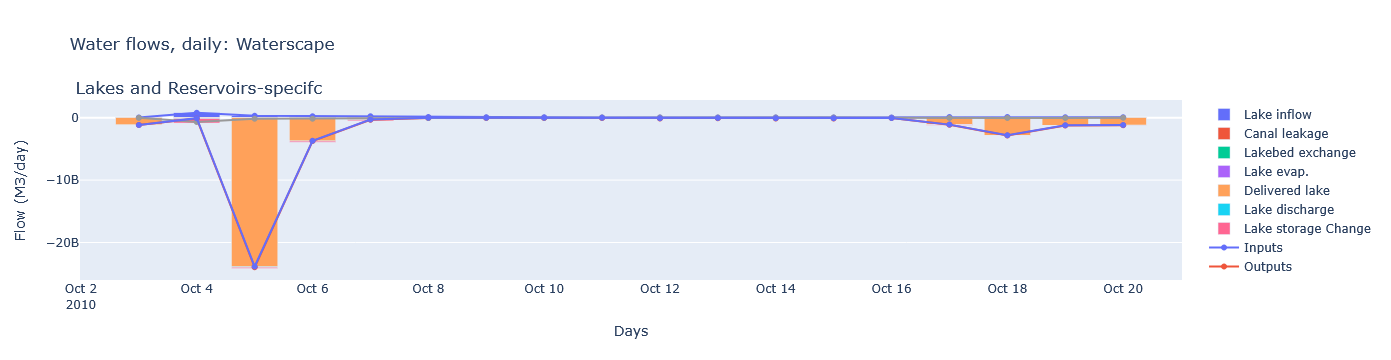

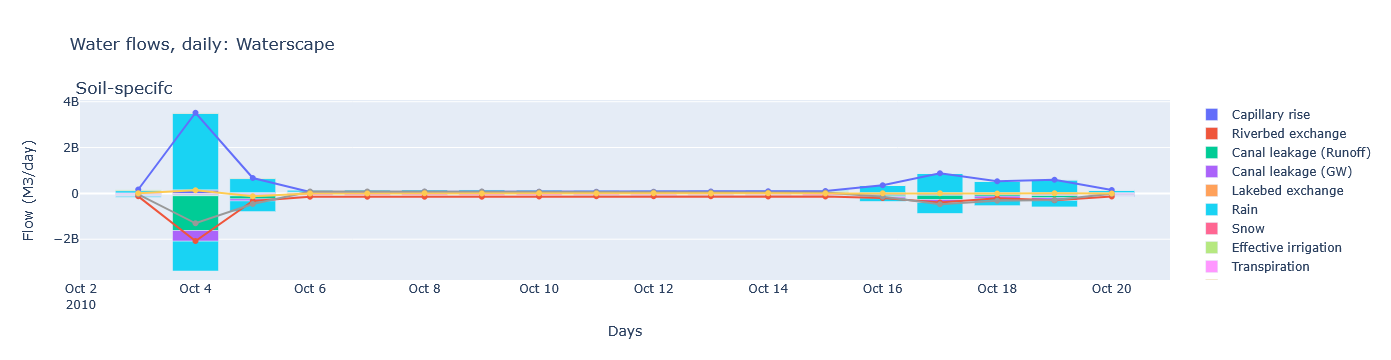

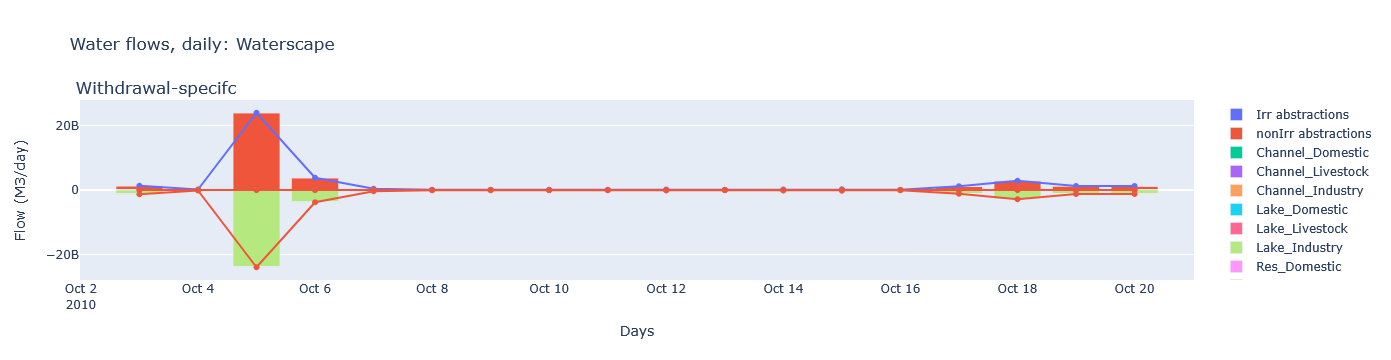

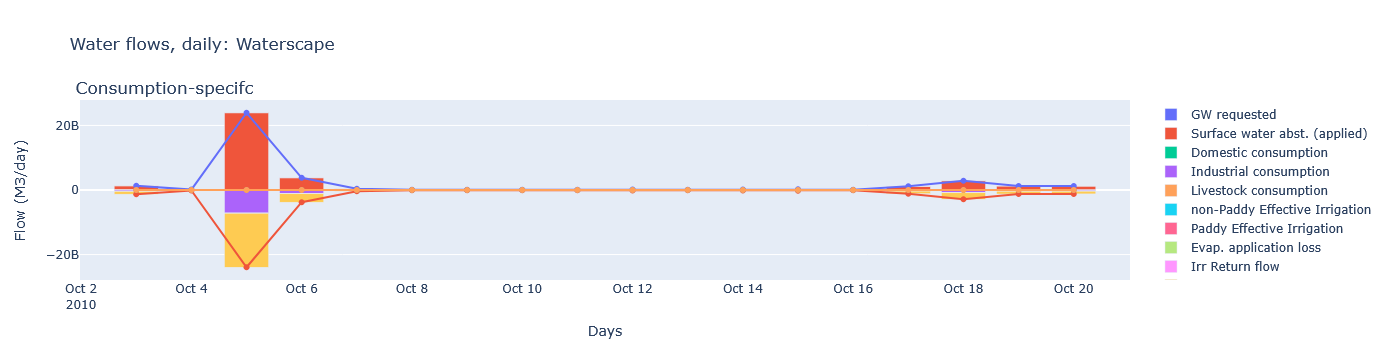

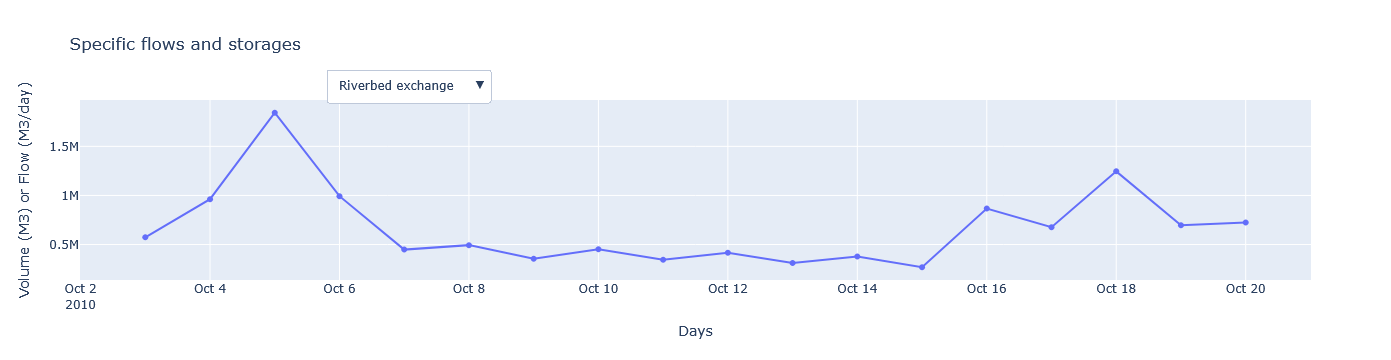

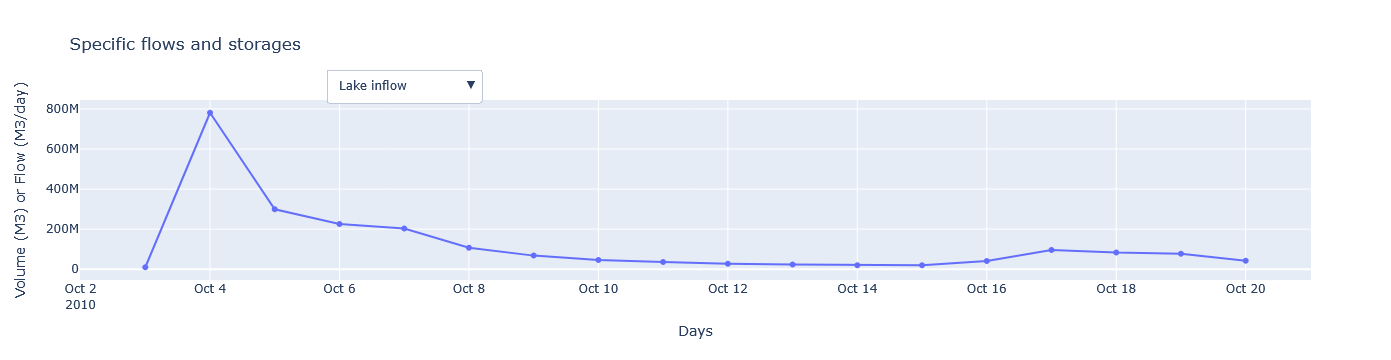

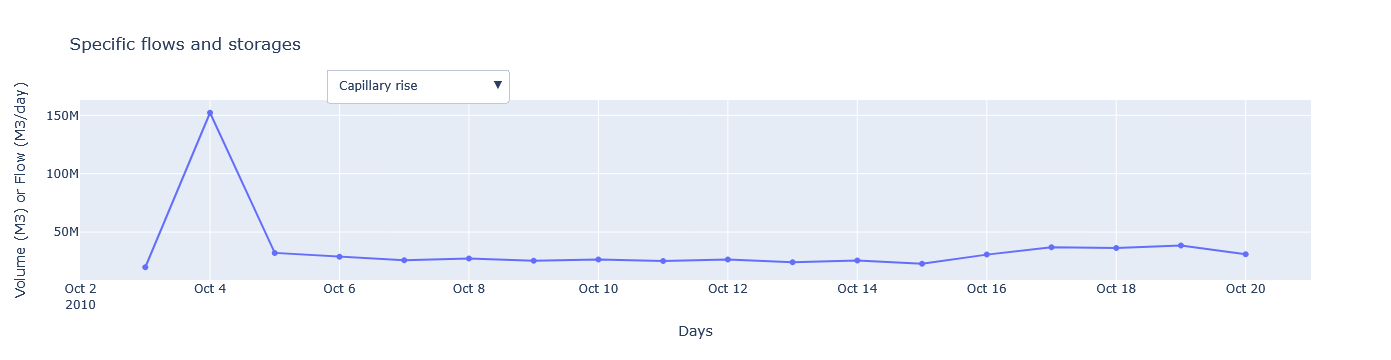

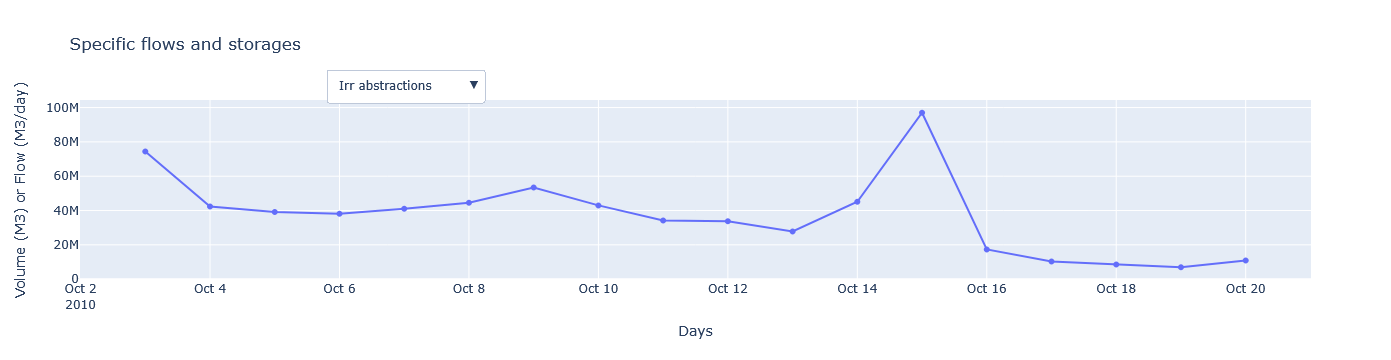

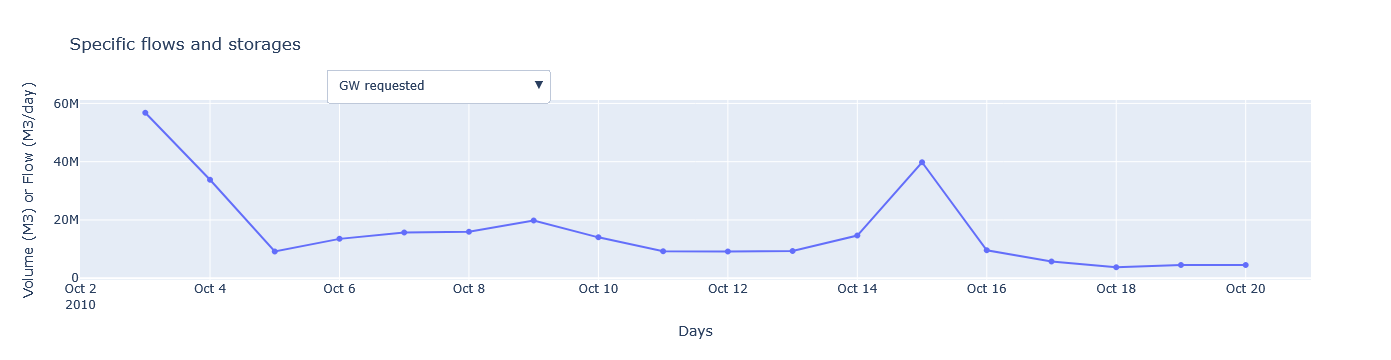

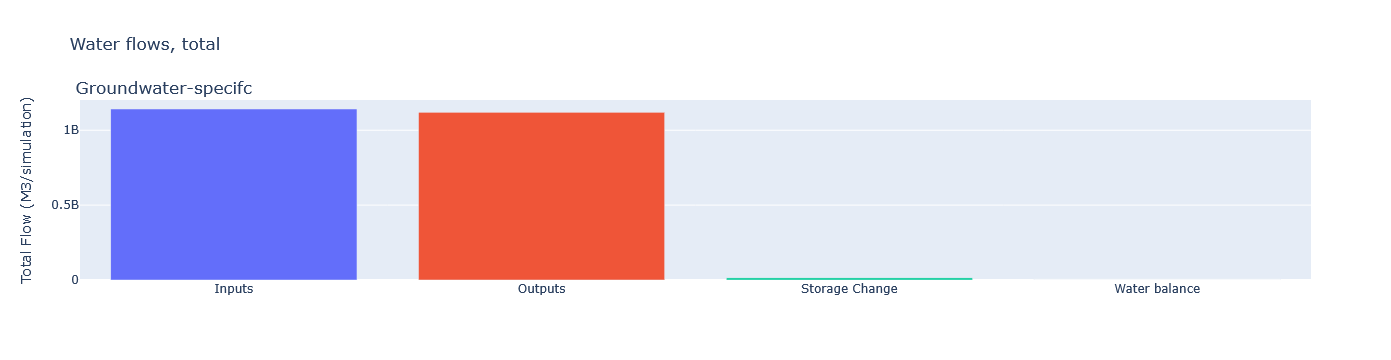

"Water flows, total: Groundwater-specifc",BMC
Inputs,1.141694
Outputs,1.119868
Storage Change,0.013937
Balance,0.007890
Balance over all flows (%):,0.693455


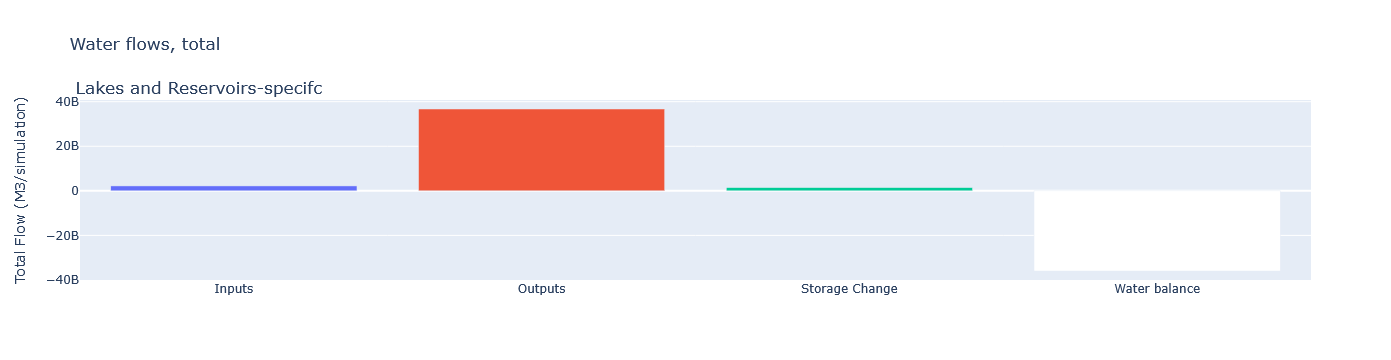

"Water flows, total: Lakes and Reservoirs-specifc",BMC
Inputs,2.202132
Outputs,36.729401
Storage Change,1.453633
Balance,-35.980902
Balance over all flows (%):,-178.188702


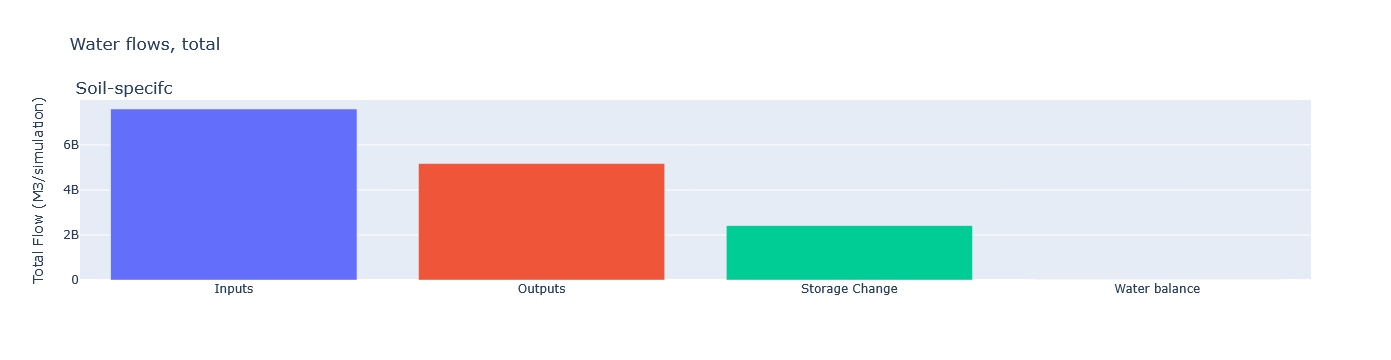

"Water flows, total: Soil-specifc",BMC
Inputs,7.596990
Outputs,5.173614
Storage Change,2.412203
Balance,0.011173
Balance over all flows (%):,0.147179


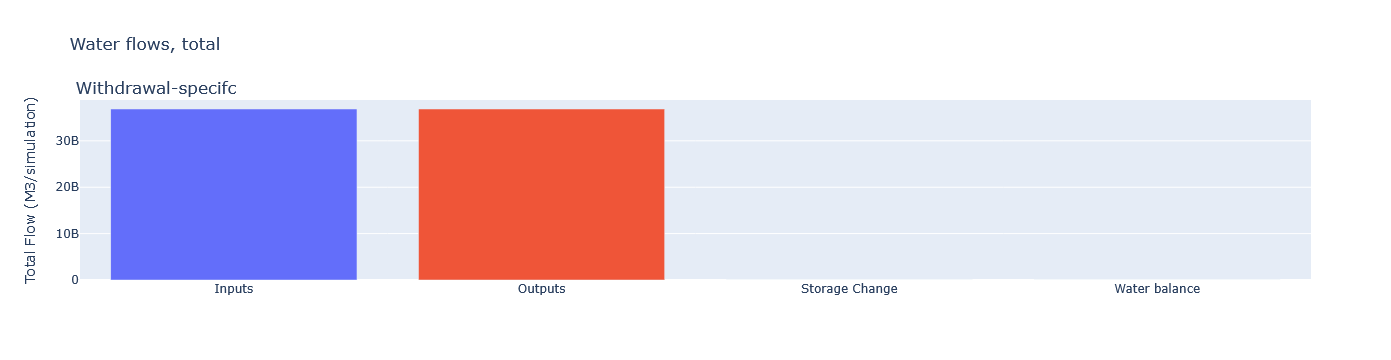

"Water flows, total: Withdrawal-specifc",BMC
Inputs,36.864837
Outputs,36.864829
Storage Change,0.000000
Balance,0.000008
Balance over all flows (%):,0.000022


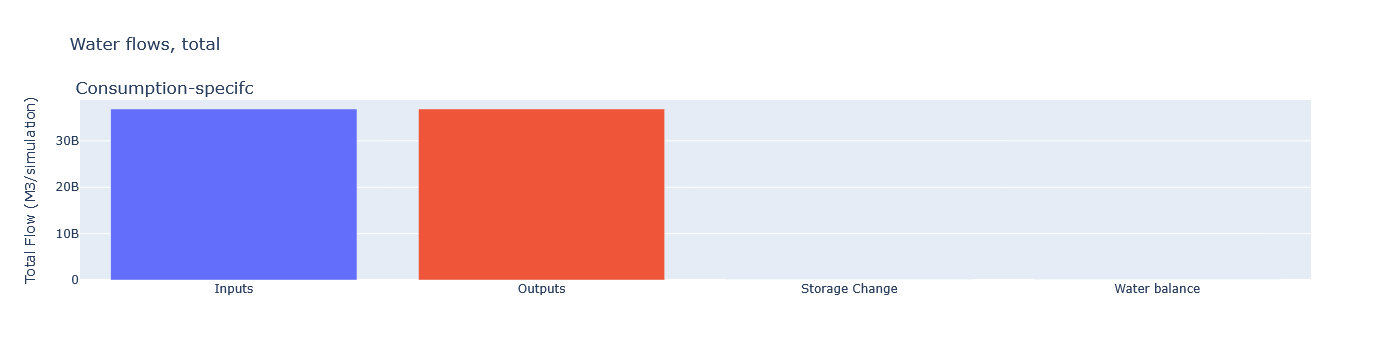

"Water flows, total: Consumption-specifc",BMC
Inputs,36.864834
Outputs,36.864828
Storage Change,0.000000
Balance,0.000006
Balance over all flows (%):,0.000016


In [15]:
"""
for name in ['Groundwater', 'Lakes and Reservoirs', 'Soil', 'Withdrawal', 'Consumption']:
    #Figures['fig_Circle_simple_'+name].show()
    #Figures['Line_WB_'+name].show()
    Figures['fig_'+name].show()   
    #Figures['fig_Circle_whole_v2_'+name].show()
"""

Names = ['Groundwater', 'Lakes and Reservoirs', 'Soil']

if withdrawals:
    Names.append('Withdrawal')
                     
if consumption:
    Names.append('Consumption')


for name in Names: #['Groundwater', 'Lakes and Reservoirs', 'Soil', 'Withdrawal', 'Consumption']:
    #Figures['Line_WB_'+name].show()
    Figures['fig_Waterscape_'+name].show()



for name in Names: #['Groundwater', 'Lakes and Reservoirs', 'Soil', 'Withdrawal', 'Consumption']:
    po.iplot(Figures['figure_'+name])
    
for name in Names: #['Groundwater', 'Lakes and Reservoirs', 'Soil', 'Withdrawal', 'Consumption']:
    Figures['Bar_WB_'+name].show()
    display(Figures['df_'+name])